#1 : Librairies et fichier

In [528]:
##Indispensables
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##PCA
from sklearn.decomposition import PCA
from sklearn import preprocessing

##Dendogramme
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


##KMeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [529]:
##Import du fichier sortie de la DataPrep
df_cleaned=pd.read_csv("cleaned_data.csv",sep=",")

#2 : PCA

##2.1 : Centrage et Réduction

In [530]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Population                 170 non-null    float64
 1   Croissance démographique   170 non-null    float64
 2   Disponibilité alimentaire  170 non-null    float64
 3   Disponibilité intérieure   170 non-null    float64
 4   Importations               170 non-null    float64
 5   Nourriture                 170 non-null    float64
 6   Production                 170 non-null    float64
 7   Consommation de poulet     170 non-null    float64
 8   Distance                   170 non-null    float64
 9   Inflation                  170 non-null    float64
 10  PIB par hab                170 non-null    float64
 11  Part des céréales          170 non-null    float64
 12  Sous-alimentation          170 non-null    float64
 13  Stabilité politique        170 non-null    float64

In [531]:
display(df_cleaned.head())

,Population,Croissance démographique,Disponibilité alimentaire,Disponibilité intérieure,Importations,Nourriture,Production,Consommation de poulet,Distance,Inflation,PIB par hab,Part des céréales,Sous-alimentation,Stabilité politique,Zone
0,36296113.0,78.88,1.53,57.0,29.0,55.0,28.0,1.52,5590.381,3.58,2953.0,71.0,21.3,-2.79,Afghanistan
1,57009756.0,28.52,35.69,2118.0,514.0,2035.0,1667.0,35.70,8692.812,6.50,14591.0,51.0,6.1,-0.28,Afrique du Sud
2,2884169.0,-7.88,16.36,47.0,38.0,47.0,13.0,16.30,1603.534,2.29,14155.0,34.0,4.3,0.37,Albanie
3,41389189.0,36.04,6.38,277.0,2.0,264.0,275.0,6.38,1340.390,6.66,15428.0,48.0,2.5,-0.92,Algérie
4,82658409.0,2.12,19.47,1739.0,842.0,1609.0,1514.0,19.47,880.187,1.44,61992.0,27.0,2.5,0.57,Allemagne


In [532]:
#On passe les pays en index, et on stocke la liste des pays et les noms de colonne dans des variables

df_cleaned.index=df_cleaned["Zone"]
df_cleaned.index.name = None
df_cleaned=df_cleaned.drop(columns="Zone")

pays=df_cleaned.index
features=df_cleaned.columns

In [533]:
#On scale, fit et transforme nos données
scaled_data=preprocessing.StandardScaler().fit_transform(df_cleaned)

#On espère une moyenne à 0 et un écart type à 1
pd.DataFrame(scaled_data).describe().round(2).loc[['mean','std'], :]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
mean,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [534]:
#On instancie notre PCA
pca=PCA()

#On l'entraîne sur les données scalées
pca.fit(scaled_data)
pca_data=pca.transform(scaled_data)

pca_data est un tableau avec les données issues de notre PCA

In [535]:
df_pca=pd.DataFrame(pca_data) ##conversion en df
display(df_pca)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,3.698489,1.559873,-0.125258,0.712952,-0.781023,-0.787358,-1.355114,0.291928,-0.105084,-1.125479,0.458615,0.029313,0.029465,-0.007213
1,-1.281367,0.975771,0.820274,1.734381,0.433809,1.302993,-0.887059,0.474077,-0.092799,0.363961,0.200266,-0.076753,-0.030772,0.012836
2,-0.339026,-1.004225,-1.204968,-1.179214,0.561119,0.063098,-0.303180,0.509664,-0.007083,0.402022,-0.594710,-0.033441,-0.025473,0.001052
3,1.182090,0.247257,-1.447923,-0.309948,0.542947,-0.657437,-0.655042,-0.568084,-0.216491,0.013675,-0.207986,-0.016540,-0.019453,-0.001086
4,-2.749137,-0.091903,-2.882150,2.164971,-0.041607,2.201157,-0.049870,0.978740,-0.013576,-0.118805,-0.430615,0.124290,-0.027703,0.022522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,-1.170658,-0.877739,0.252164,5.337666,-2.661489,-2.083710,0.519386,-2.047334,0.301678,0.692046,-0.643363,0.022653,-0.018019,0.004207
166,0.515775,-0.073496,0.594557,-0.155225,0.480244,-0.167995,0.349975,-0.179830,-0.018451,-0.087613,-0.304629,-0.028526,-0.014823,0.000230
167,-9.838227,10.259273,0.983484,-0.473875,-0.282423,-2.914392,1.620655,1.240926,-3.217779,0.172639,0.199300,0.014228,0.010177,0.000178
168,3.167109,1.351735,0.120320,-0.067368,-0.932418,0.095801,-0.908840,-0.468693,-0.051976,-0.388308,0.705121,0.058675,0.006137,-0.023094


df_pca est le df contenant les données issues de notre PCA

##2.2 : Variance expliquée et Scree plot

In [536]:
#On calcule les pourcentages de variance expliquée
per_var=np.round(pca.explained_variance_ratio_*100,decimals=1)

#On calcule également les sommes cumulées de nos variances expliquées
scree_cum=np.cumsum(per_var)

#On crée une liste d'étiquettes avec les noms de nos composantes principales
labels=['PC'+str(x) for x in range (1, len(per_var)+1)]

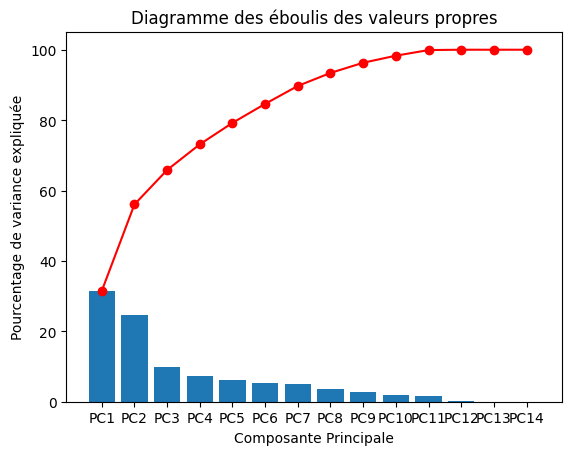

In [537]:
#On affiche tout cela graphiquement
plt.bar(x=range(1,len(per_var)+1),height=per_var,tick_label=labels)
plt.plot(range(1,len(per_var)+1), scree_cum,c="red",marker='o')
plt.ylabel('Pourcentage de variance expliquée')
plt.xlabel('Composante Principale')
plt.title('Diagramme des éboulis des valeurs propres')
plt.show()

On conserve les 6 premières composantes pour une variance expliquée de 84%

##2.3 : Composantes

<Axes: >

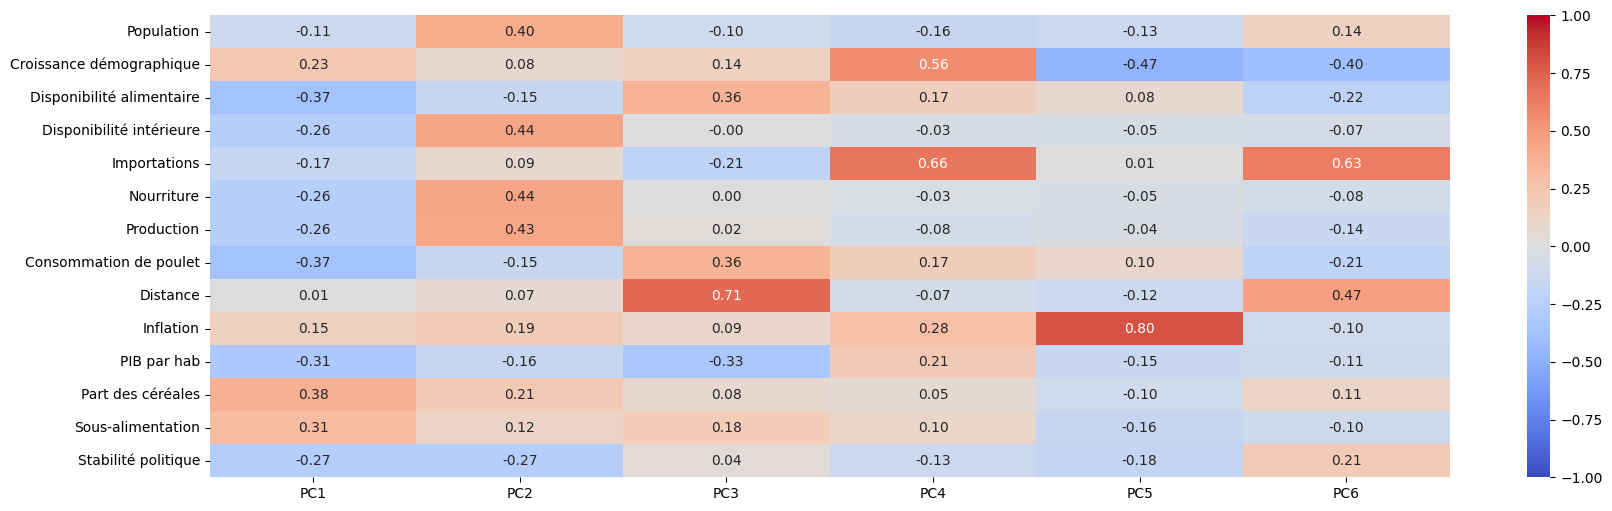

In [538]:
#On a les coordonnées de nos variables originelles dans la nouvelle base des PC (et vice-versa)
pcs = pca.components_
pcs = pd.DataFrame(pcs)
pcs.columns = features
pcs.index = [f"PC{i}" for i in range(1, len(per_var)+1)]
pcs.round(2)

#Représentation visuelle
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.head(6).T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

##2.4 : Graphe des corrélations

###2.4.1 : Sur (PC1,PC2)

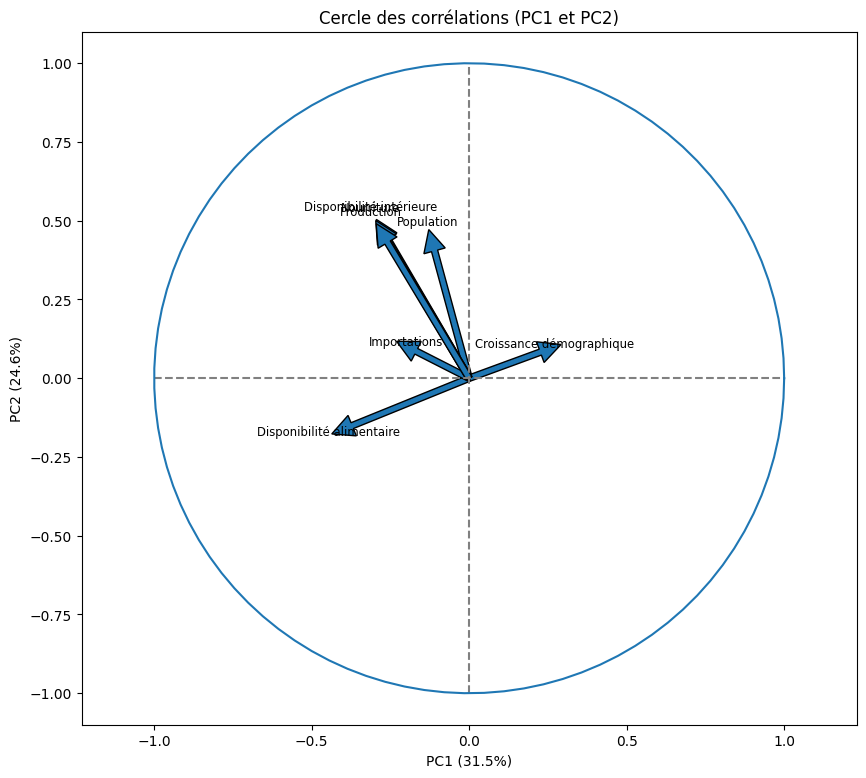

In [539]:
##On trace les vecteurs de nos variables projetées sur le plan (PC1,PC2)
##Pour améliorer la lisibilité, on sépare nos variables en 2 groupes arbitraires

x, y = 0,1

fig, ax = plt.subplots(figsize=(10, 9))
for i in range(0, round(pca.components_.shape[1]/2)):
  ##Tracé du vecteur
    ax.arrow(0,
             0,
             pca.components_[0, i],  #0 pour PC1
             pca.components_[1, i],  #1 pour PC2
             head_width=0.07,
             head_length=0.07,
             width=0.02,              )

    ##Etiquette
    plt.text(pca.components_[0, i] * 1.2,
             pca.components_[1, i] * 1.2,
             features[i],
             color = 'black',
             ha = 'center',
             va = 'baseline',
             fontsize = 'small')

##Affichage des lignes horizontales et verticales
plt.plot([-1, 1], [0, 0], color='grey', ls='--')
plt.plot([0, 0], [-1, 1], color='grey', ls='--')


##Nom des axes, avec le pourcentage d'inertie expliqué
plt.xlabel('PC{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
plt.ylabel('PC{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

plt.title("Cercle des corrélations (PC{} et PC{})".format(x+1, y+1))


an = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale
plt.axis('equal')
plt.show(block=False)

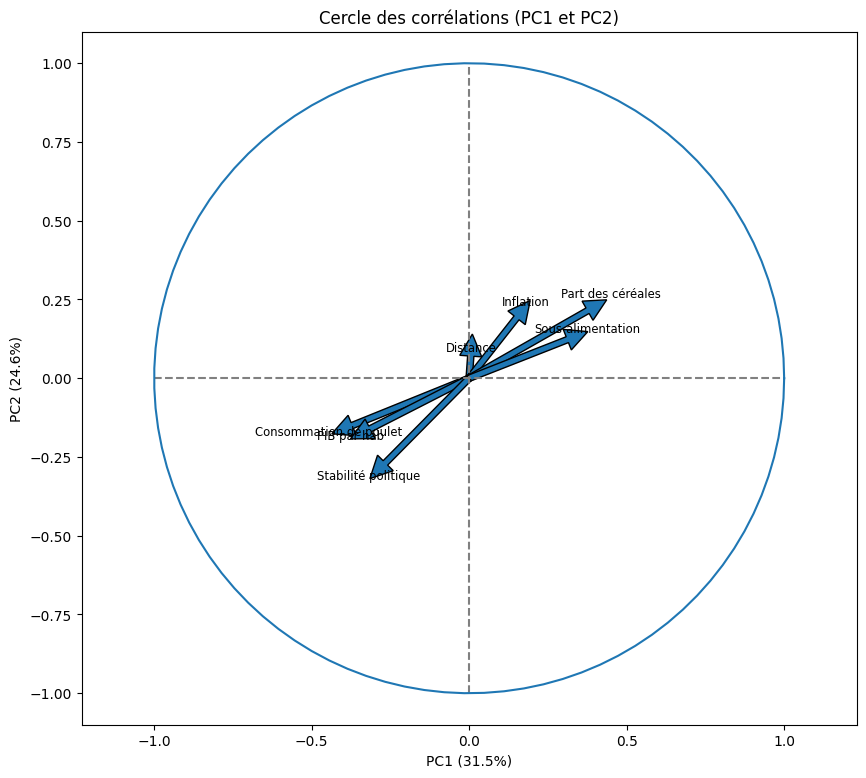

In [540]:
x, y = 0,1

fig, ax = plt.subplots(figsize=(10, 9))
for i in range(round(pca.components_.shape[1]/2), pca.components_.shape[1]):
    ##Vecteur
    ax.arrow(0,
             0,
             pca.components_[0, i],
             pca.components_[1, i],
             head_width=0.07,
             head_length=0.07,
             width=0.02,              )

 ##Etiquette
    plt.text(pca.components_[0, i] * 1.2,
             pca.components_[1, i] * 1.2,
             features[i],
             color = 'black',
             ha = 'center',
             va = 'baseline',
             fontsize = 'small')

# affichage des lignes horizontales et verticales
plt.plot([-1, 1], [0, 0], color='grey', ls='--')
plt.plot([0, 0], [-1, 1], color='grey', ls='--')


# nom des axes, avec le pourcentage d'inertie expliqué
plt.xlabel('PC{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
plt.ylabel('PC{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

plt.title("Cercle des corrélations (PC{} et PC{})".format(x+1, y+1))


an = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(an), np.sin(an))
plt.axis('equal')
plt.show(block=False)

###2.4.2 : Sur (PC2,PC3)

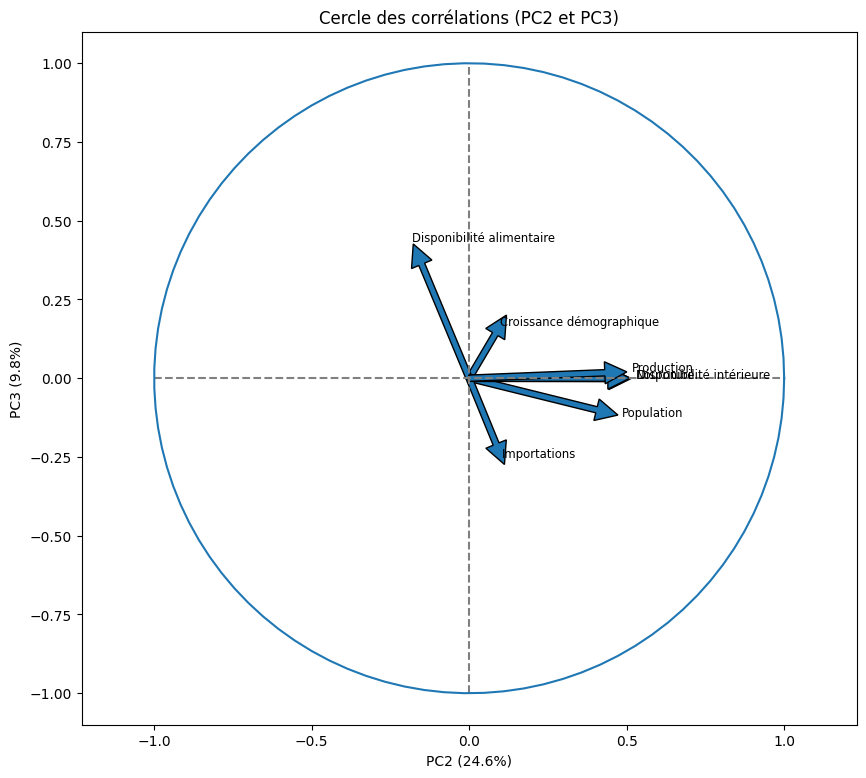

In [541]:
##Procédons de la même façon pour les deux composantes suivantes

x, y = 1,2

fig, ax = plt.subplots(figsize=(10, 9))
for i in range(0, round(pca.components_.shape[1]/2)):
  ##Vecteur
    ax.arrow(0,
             0,
             pca.components_[x, i],
             pca.components_[y, i],
             head_width=0.07,
             head_length=0.07,
             width=0.02,              )
##Etiquette
    plt.text(pca.components_[x, i] * 1.2,
             pca.components_[y, i] * 1.2,
             features[i],
             color = 'black',
             ha = 'left',
             va = 'baseline',
             fontsize = 'small')

##Affichage des lignes horizontales et verticales
plt.plot([-1, 1], [0, 0], color='grey', ls='--')
plt.plot([0, 0], [-1, 1], color='grey', ls='--')


##Nom des axes, avec le pourcentage d'inertie expliqué
plt.xlabel('PC{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
plt.ylabel('PC{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

plt.title("Cercle des corrélations (PC{} et PC{})".format(x+1, y+1))


an = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(an), np.sin(an))
plt.axis('equal')
plt.show(block=False)

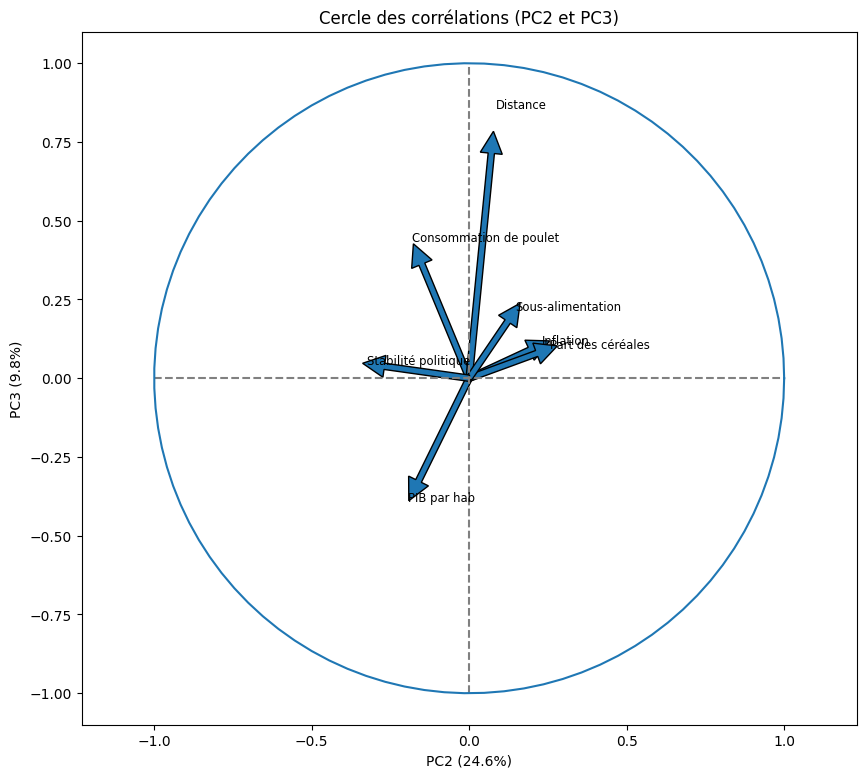

In [542]:
x, y = 1,2

fig, ax = plt.subplots(figsize=(10, 9))
for i in range(round(pca.components_.shape[1]/2), pca.components_.shape[1]):
  ##Vecteur
    ax.arrow(0,
             0,
             pca.components_[x, i],
             pca.components_[y, i],
             head_width=0.07,
             head_length=0.07,
             width=0.02,              )

    plt.text(pca.components_[x, i] * 1.2,
             pca.components_[y, i] * 1.2,
             features[i],
             color = 'black',
             ha = 'left',
             va = 'baseline',
             fontsize = 'small')

##Affichage des lignes horizontales et verticales
plt.plot([-1, 1], [0, 0], color='grey', ls='--')
plt.plot([0, 0], [-1, 1], color='grey', ls='--')


##Nom des axes, avec le pourcentage d'inertie expliqué
plt.xlabel('PC{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
plt.ylabel('PC{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

plt.title("Cercle des corrélations (PC{} et PC{})".format(x+1, y+1))


an = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(an), np.sin(an))
plt.axis('equal')
plt.show(block=False)

##2.5 : Projection

In [543]:
#On calcule les coordonnées de nos individus dans le nouvel espace
X_proj = pca.transform(scaled_data)
X_proj[:6]

array([[ 3.69848887e+00,  1.55987260e+00, -1.25257584e-01,
         7.12952343e-01, -7.81022818e-01, -7.87357991e-01,
        -1.35511441e+00,  2.91928497e-01, -1.05084463e-01,
        -1.12547884e+00,  4.58615485e-01,  2.93130042e-02,
         2.94648679e-02, -7.21253872e-03],
       [-1.28136657e+00,  9.75770636e-01,  8.20273710e-01,
         1.73438065e+00,  4.33808691e-01,  1.30299312e+00,
        -8.87059472e-01,  4.74076657e-01, -9.27993314e-02,
         3.63960811e-01,  2.00266225e-01, -7.67525138e-02,
        -3.07719486e-02,  1.28360004e-02],
       [-3.39025957e-01, -1.00422472e+00, -1.20496814e+00,
        -1.17921402e+00,  5.61118955e-01,  6.30981401e-02,
        -3.03179913e-01,  5.09663793e-01, -7.08328441e-03,
         4.02021651e-01, -5.94710437e-01, -3.34411057e-02,
        -2.54734535e-02,  1.05158105e-03],
       [ 1.18208989e+00,  2.47256666e-01, -1.44792275e+00,
        -3.09947603e-01,  5.42946842e-01, -6.57436608e-01,
        -6.55042048e-01, -5.68084075e-01, -2.

In [544]:
##Fonction pour le graphique, à appeler pour chaque plan

def display_factorial_planes(   X_projected,
                                x_y,
                                pca=None,
                                labels = None,
                                clusters=None,
                                alpha=1,
                                figsize=[10,8],
                                color=None,
                                marker=".",
                                palette=None ):

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize:
        figsize = (7,6)

    # On gère les labels
    if  labels is None :
        labels = []
    try :
        len(labels)
    except Exception as e :
        raise e

    # On vérifie la variable axis
    if not len(x_y) ==2 :
        raise AttributeError("2 axes sont demandées")
    if max(x_y )>= X_.shape[1] :
        raise AttributeError("la variable axis n'est pas bonne")

    # on définit x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # Les points
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c, palette=palette)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe
    if pca :
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else :
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'PC{x+1} {v1}')
    ax.set_ylabel(f'PC{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) :
        # j'ai copié collé la fonction sans la lire
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')

    # Titre et display
    plt.title(f"Projection des individus (sur PC{x+1} et PC{y+1})")
    plt.show()

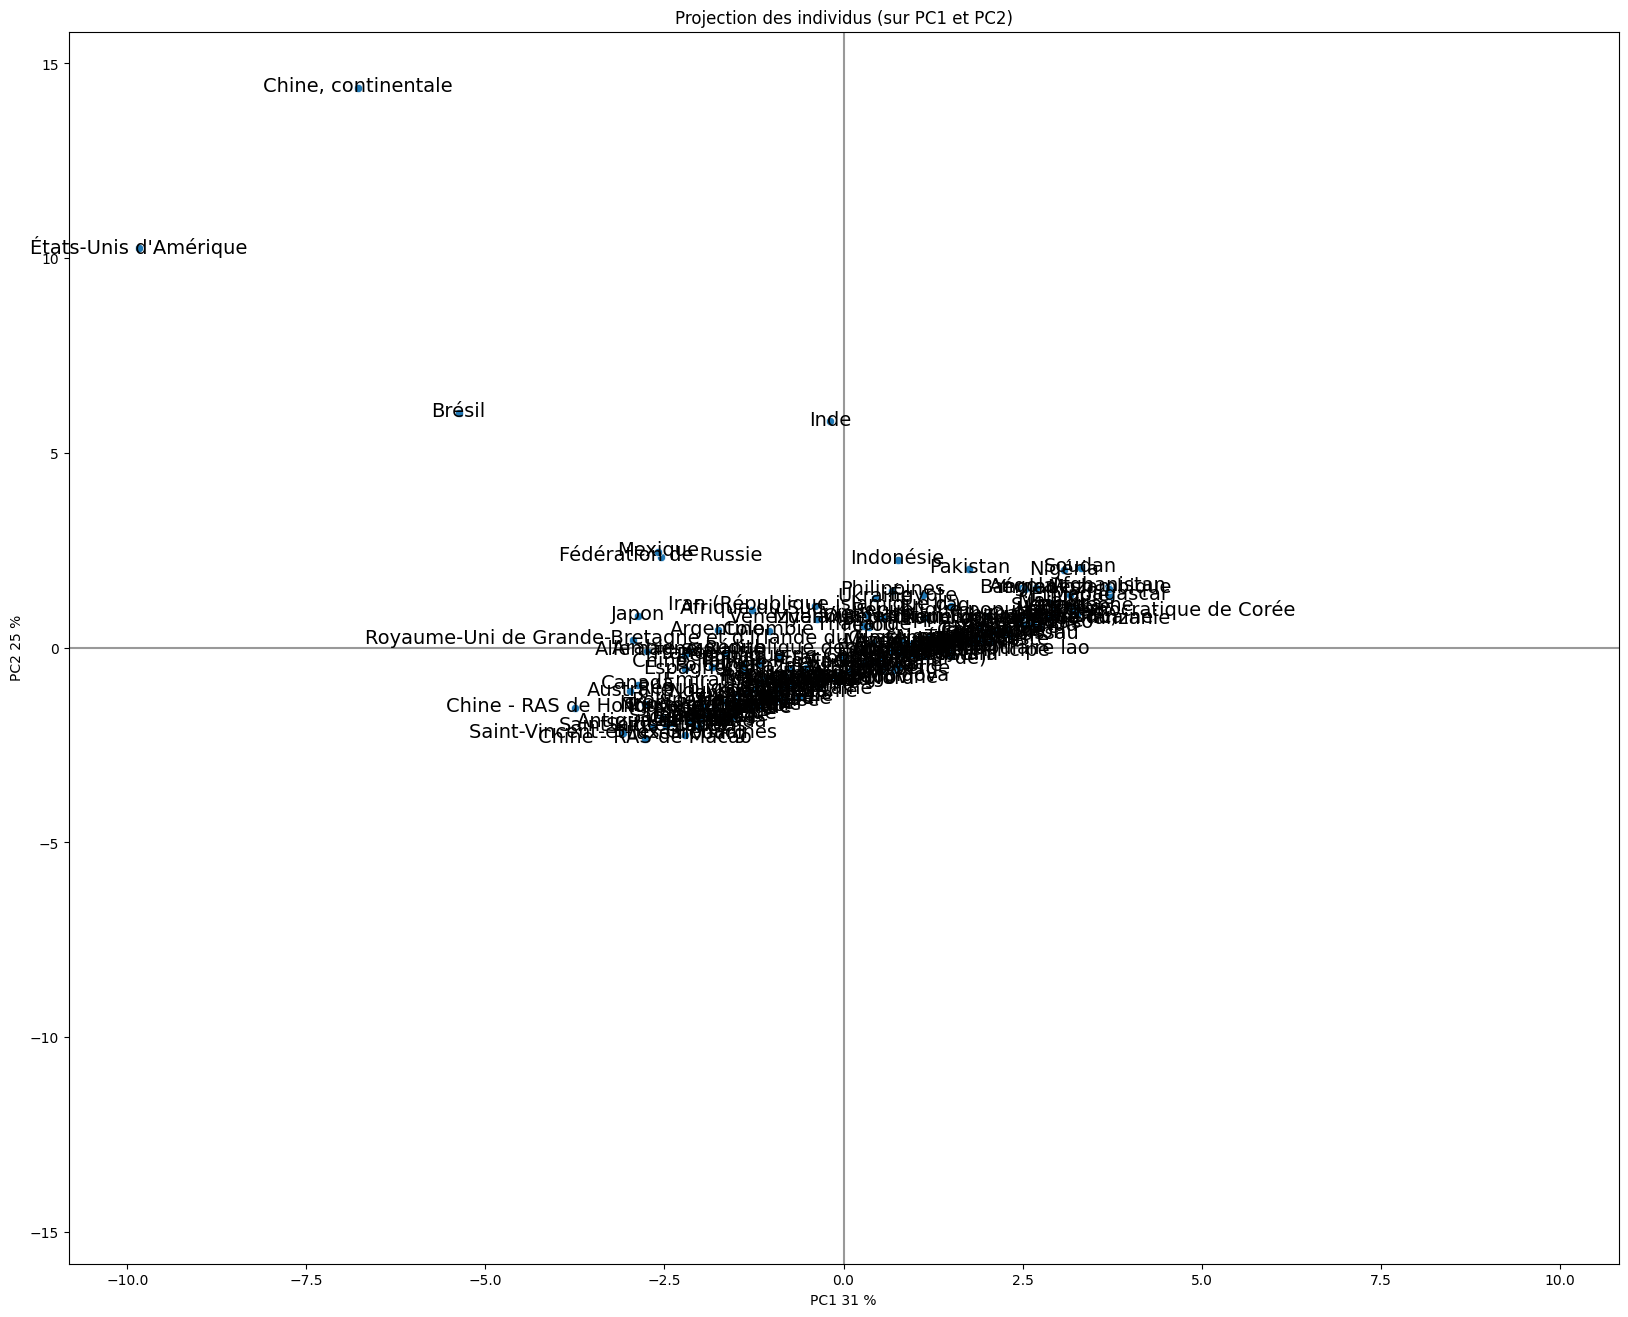

In [545]:
#Graphique pour (PC1,PC2)
x_y = [0,1]
display_factorial_planes(X_proj, x_y, pca,labels=pays, figsize=(20,16), marker="o")

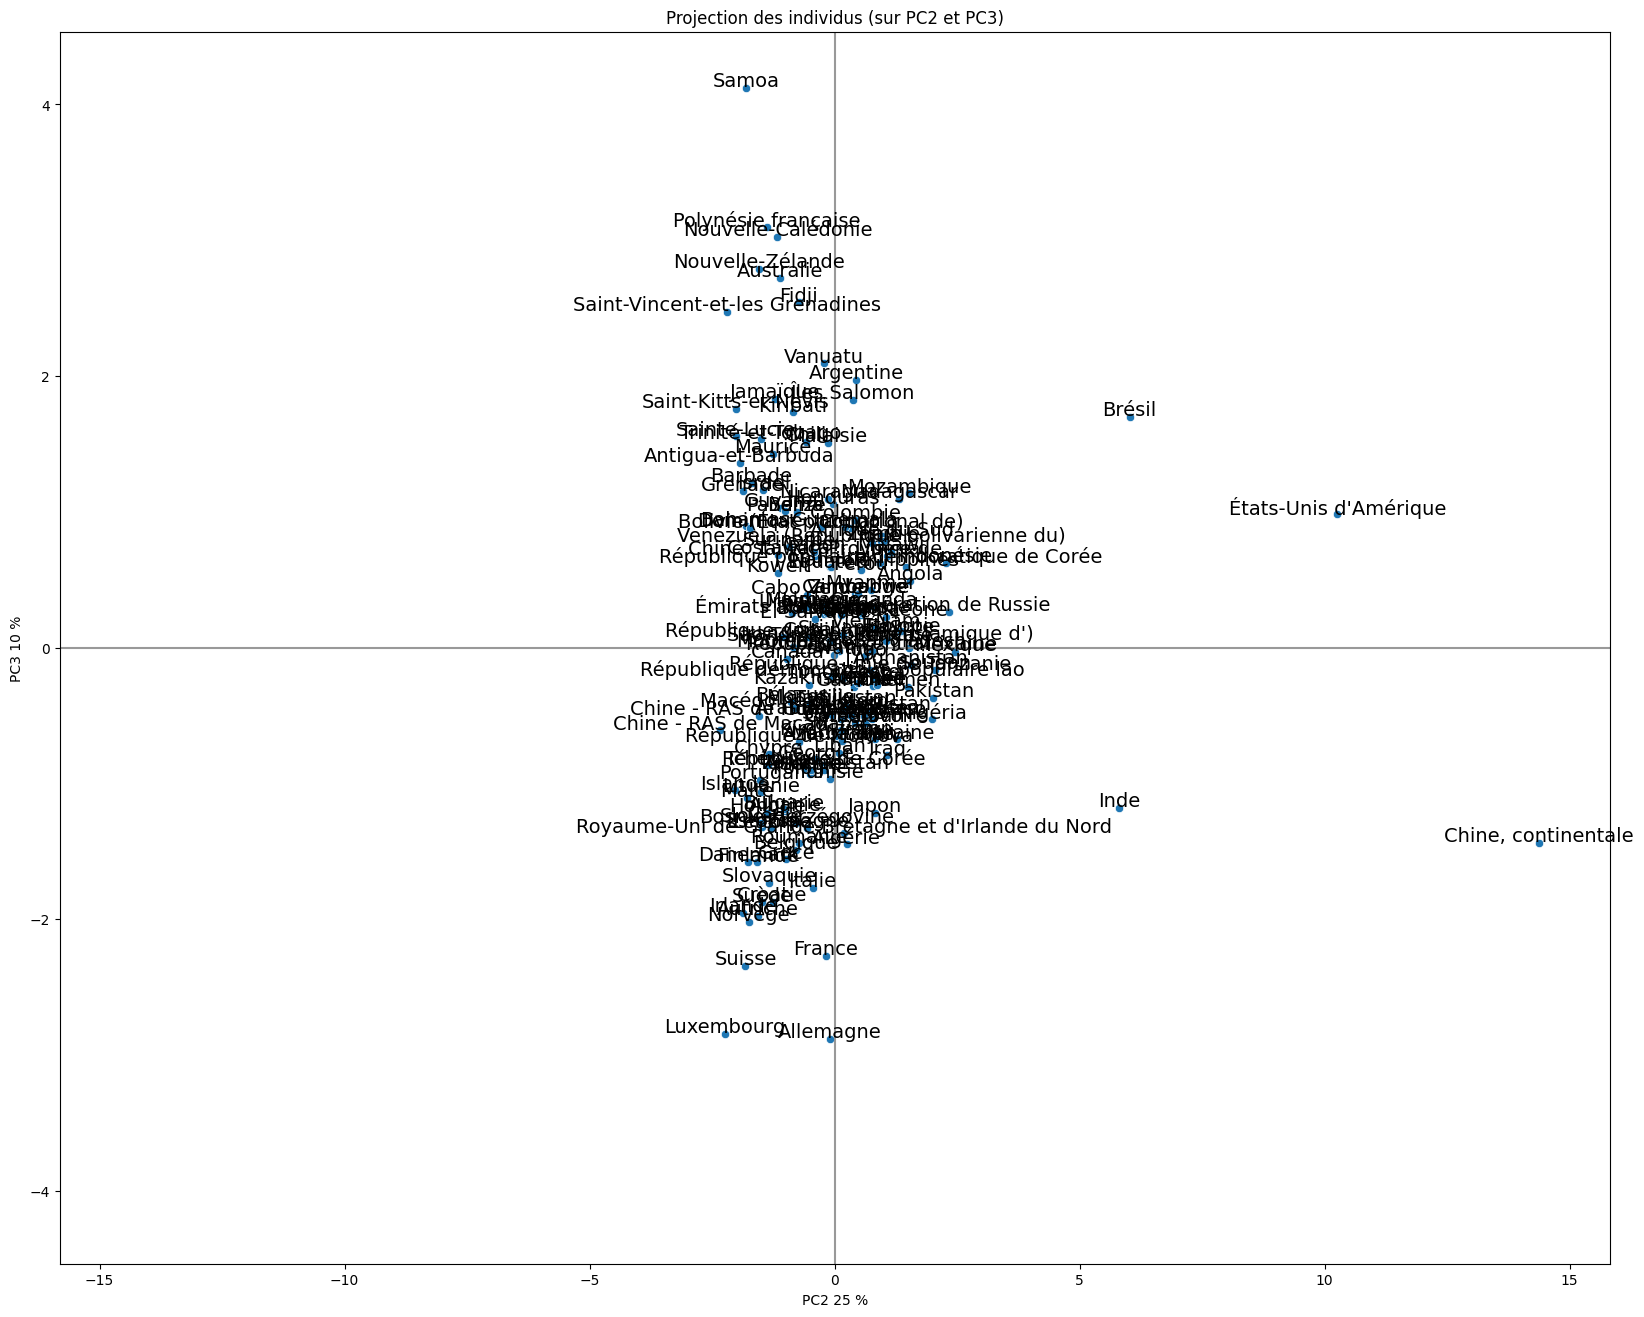

In [546]:
#Idem pour (PC2,PC3)
x_y = 1,2
display_factorial_planes(X_proj, x_y, pca, labels=pays, figsize=(20,16),marker="o")

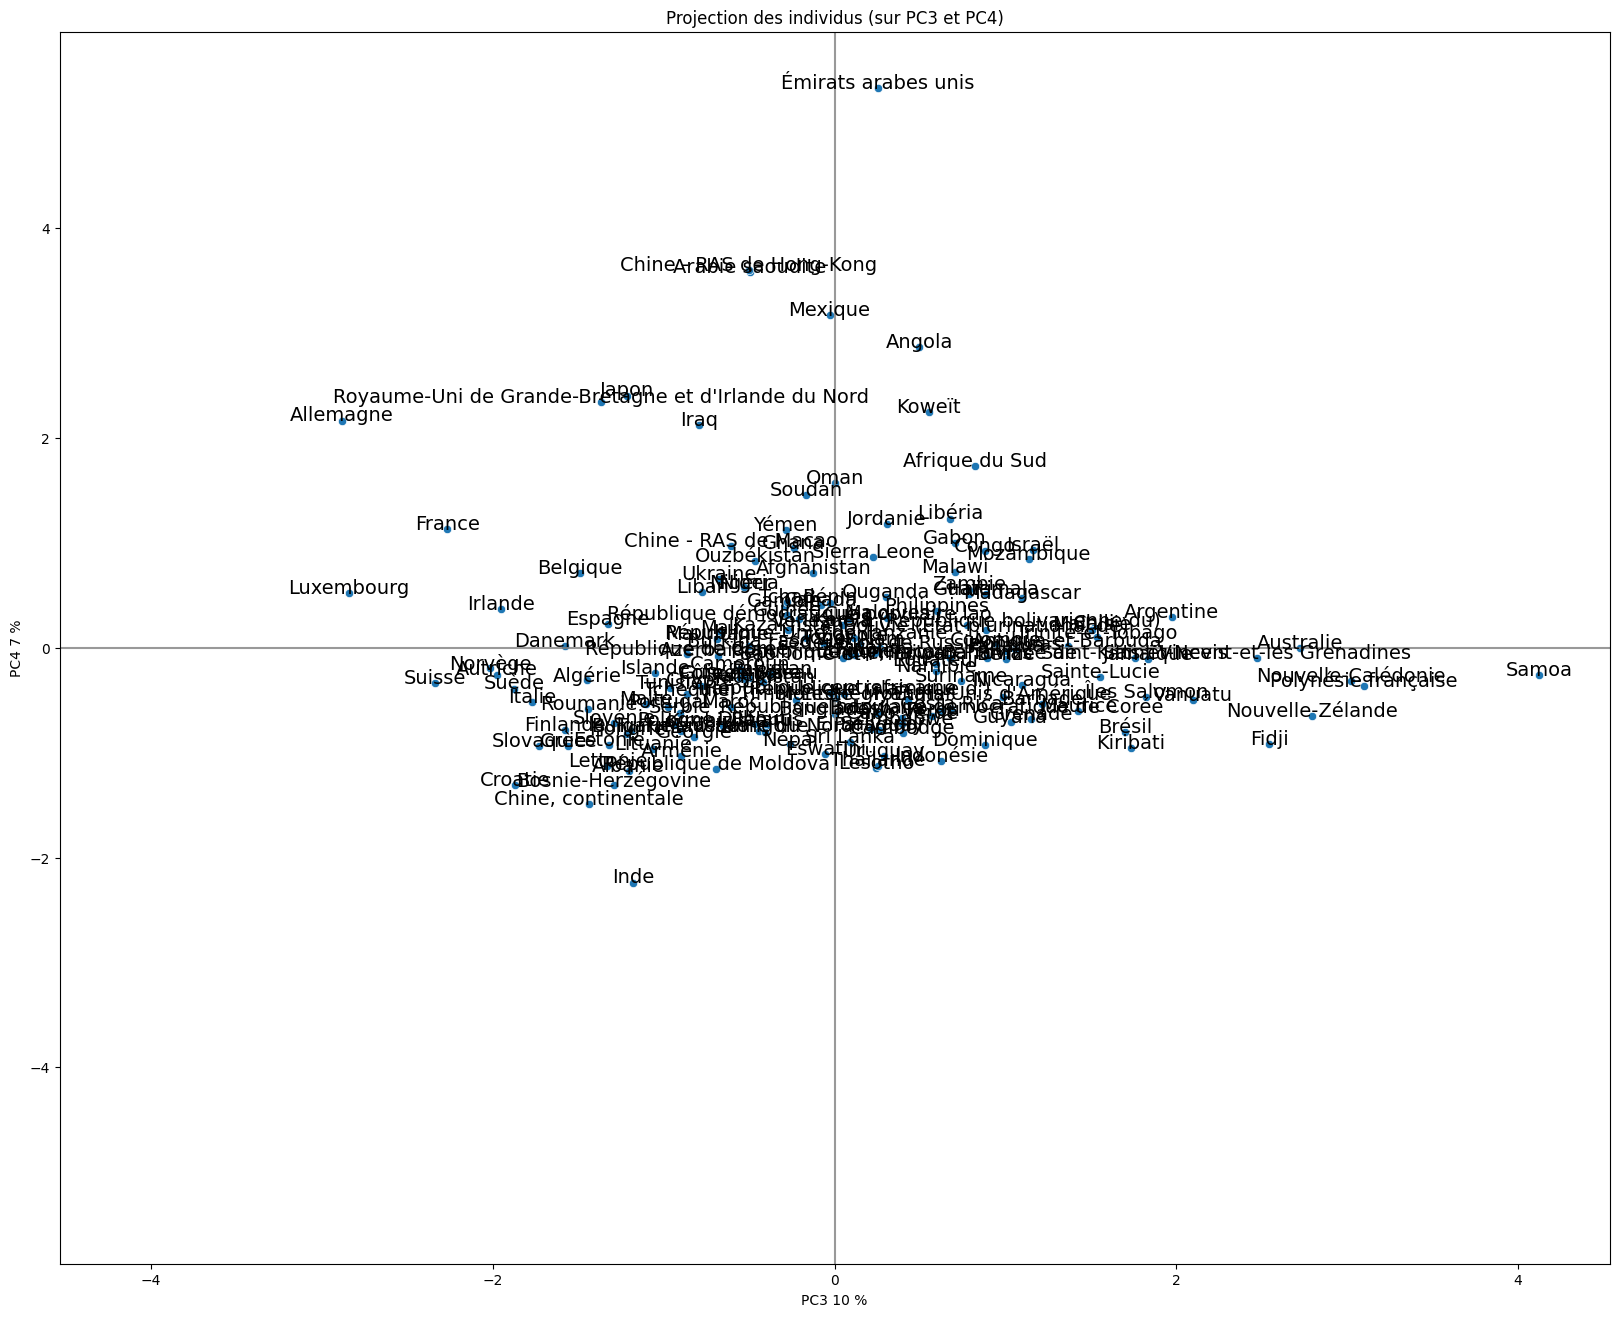

In [547]:
##Pour(PC3,PC4)
x_y = 2,3
display_factorial_planes(X_proj, x_y, pca, labels=pays, figsize=(20,16),marker="o")

#3 : Dendogramme

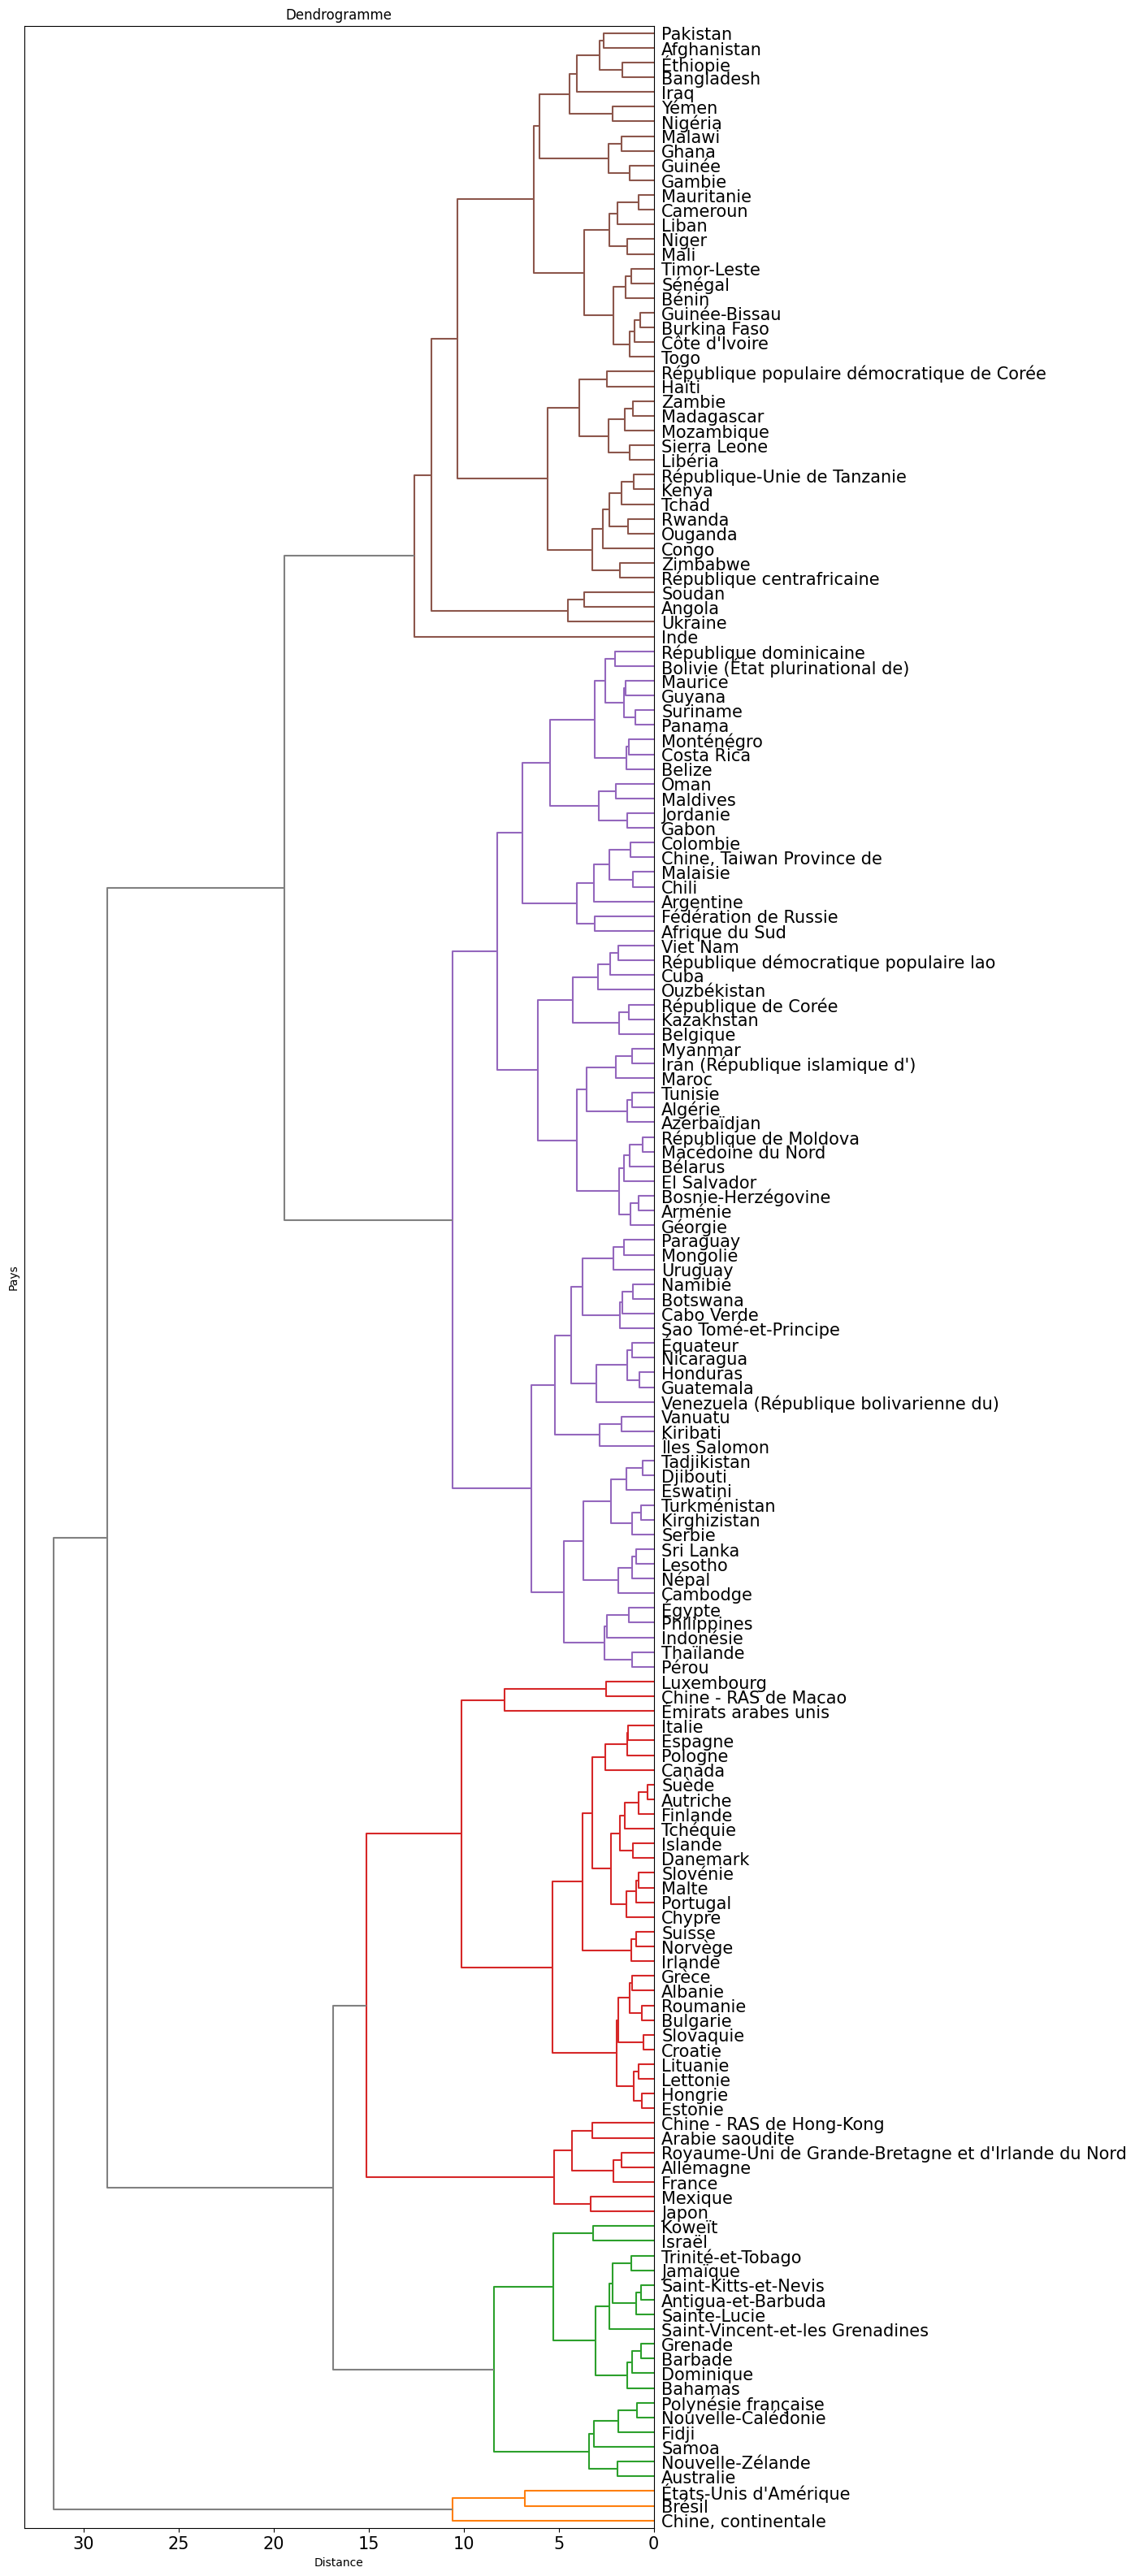

In [548]:
##Calcul des distances
Z = linkage(df_pca, method="ward")

##Initialisation de la figure
fig, ax = plt.subplots(1, 1, figsize=(10,40))

##Couleurs des clusters
n_clusters_to_color = 5
color_threshold = Z[-(n_clusters_to_color - 1), 2]
dendrogram(Z, p=5, ax=ax, labels=pays, orientation = "left",color_threshold=color_threshold, above_threshold_color='grey' )

plt.title("Dendrogramme")
ax.set_xlabel("Distance")
ax.set_ylabel("Pays")
ax.tick_params(axis='x', which='major', labelsize=15)
ax.tick_params(axis='y', which='major', labelsize=15)

#4 : K-means

##4.2 : Nombre de clusters

On va appliquer l'algorithme K-means pour identifier nos clusters

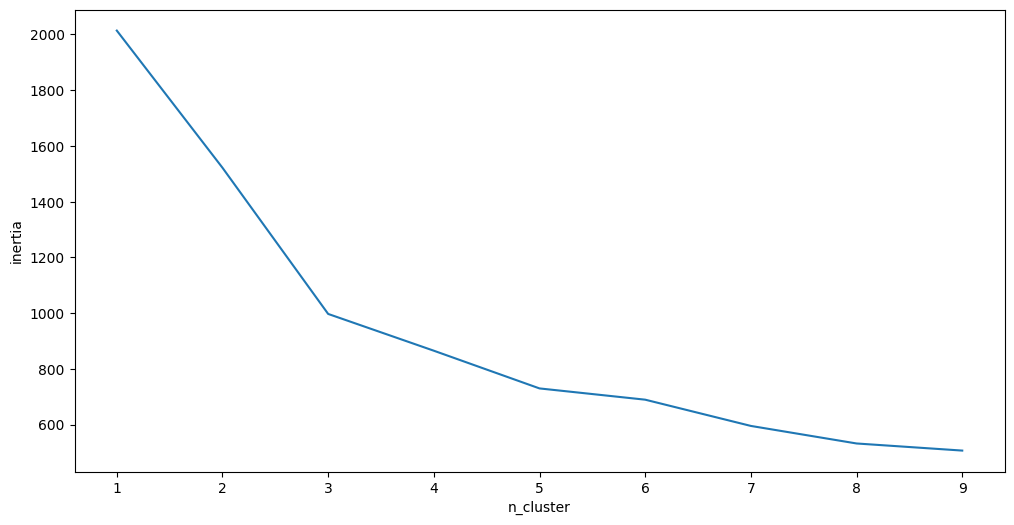

In [549]:
##On calcule les inerties pour identifier un nombre pertinent de clusters

# Une liste vide pour enregistrer les inerties :
inertia_list = [ ]

# Notre liste de nombres de clusters :
k_list = range(1, 10)

# Pour chaque nombre de clusters :
for k in k_list :

    # On instancie un k-means pour k clusters
    kmeans = KMeans(n_clusters=k,random_state=43)

    # On entraine
    kmeans.fit(X_proj[:,:6])

    # On enregistre l'inertie obtenue :
    inertia_list.append(kmeans.inertia_)

##On affiche le résultat
fig, ax = plt.subplots(1,1,figsize=(12,6))

ax.set_ylabel("inertia")
ax.set_xlabel("n_cluster")
ax = plt.plot(k_list, inertia_list)


In [550]:
##On affiche le silhouette score pour plusieurs nombres de clusters,
##afin d'identifier un nombre de clusters cohérent
for i in range(2, 10):
    km = KMeans(n_clusters=i, random_state=42)

    km.fit_predict(X_proj[:,:6])

    score = silhouette_score(X_proj[:,:6], km.labels_, metric='euclidean')

    print('Silhouette Score pour',i,'clusters : %.3f' % score)

Silhouette Score pour 2 clusters : 0.307
Silhouette Score pour 3 clusters : 0.183
Silhouette Score pour 4 clusters : 0.220
Silhouette Score pour 5 clusters : 0.264
Silhouette Score pour 6 clusters : 0.237
Silhouette Score pour 7 clusters : 0.273
Silhouette Score pour 8 clusters : 0.270
Silhouette Score pour 9 clusters : 0.257


La méthode du "coude" et le silhouette score nous indiquent l'existence de 5 clusters

##4.2 : Algorithme

In [551]:
##On fait tourner kmeans puis attribue un cluster à chaque individu
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_proj[:,:6])
dd = {i:j for i,j in enumerate(list("abcde"))}
labels = [dd[i] for i in kmeans.labels_]
labels[:10]

##On ajoute les clusters à scaled_data converti en df
scaled_df = pd.DataFrame(pca_data, index=pays, columns=features)
scaled_df["cluster"] = labels

##On affiche le df
scaled_df

,Population,Croissance démographique,Disponibilité alimentaire,Disponibilité intérieure,Importations,Nourriture,Production,Consommation de poulet,Distance,Inflation,PIB par hab,Part des céréales,Sous-alimentation,Stabilité politique,cluster
Afghanistan,3.698489,1.559873,-0.125258,0.712952,-0.781023,-0.787358,-1.355114,0.291928,-0.105084,-1.125479,0.458615,0.029313,0.029465,-0.007213,a
Afrique du Sud,-1.281367,0.975771,0.820274,1.734381,0.433809,1.302993,-0.887059,0.474077,-0.092799,0.363961,0.200266,-0.076753,-0.030772,0.012836,c
Albanie,-0.339026,-1.004225,-1.204968,-1.179214,0.561119,0.063098,-0.303180,0.509664,-0.007083,0.402022,-0.594710,-0.033441,-0.025473,0.001052,b
Algérie,1.182090,0.247257,-1.447923,-0.309948,0.542947,-0.657437,-0.655042,-0.568084,-0.216491,0.013675,-0.207986,-0.016540,-0.019453,-0.001086,e
Allemagne,-2.749137,-0.091903,-2.882150,2.164971,-0.041607,2.201157,-0.049870,0.978740,-0.013576,-0.118805,-0.430615,0.124290,-0.027703,0.022522,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Émirats arabes unis,-1.170658,-0.877739,0.252164,5.337666,-2.661489,-2.083710,0.519386,-2.047334,0.301678,0.692046,-0.643363,0.022653,-0.018019,0.004207,b
Équateur,0.515775,-0.073496,0.594557,-0.155225,0.480244,-0.167995,0.349975,-0.179830,-0.018451,-0.087613,-0.304629,-0.028526,-0.014823,0.000230,e
États-Unis d'Amérique,-9.838227,10.259273,0.983484,-0.473875,-0.282423,-2.914392,1.620655,1.240926,-3.217779,0.172639,0.199300,0.014228,0.010177,0.000178,d
Éthiopie,3.167109,1.351735,0.120320,-0.067368,-0.932418,0.095801,-0.908840,-0.468693,-0.051976,-0.388308,0.705121,0.058675,0.006137,-0.023094,e


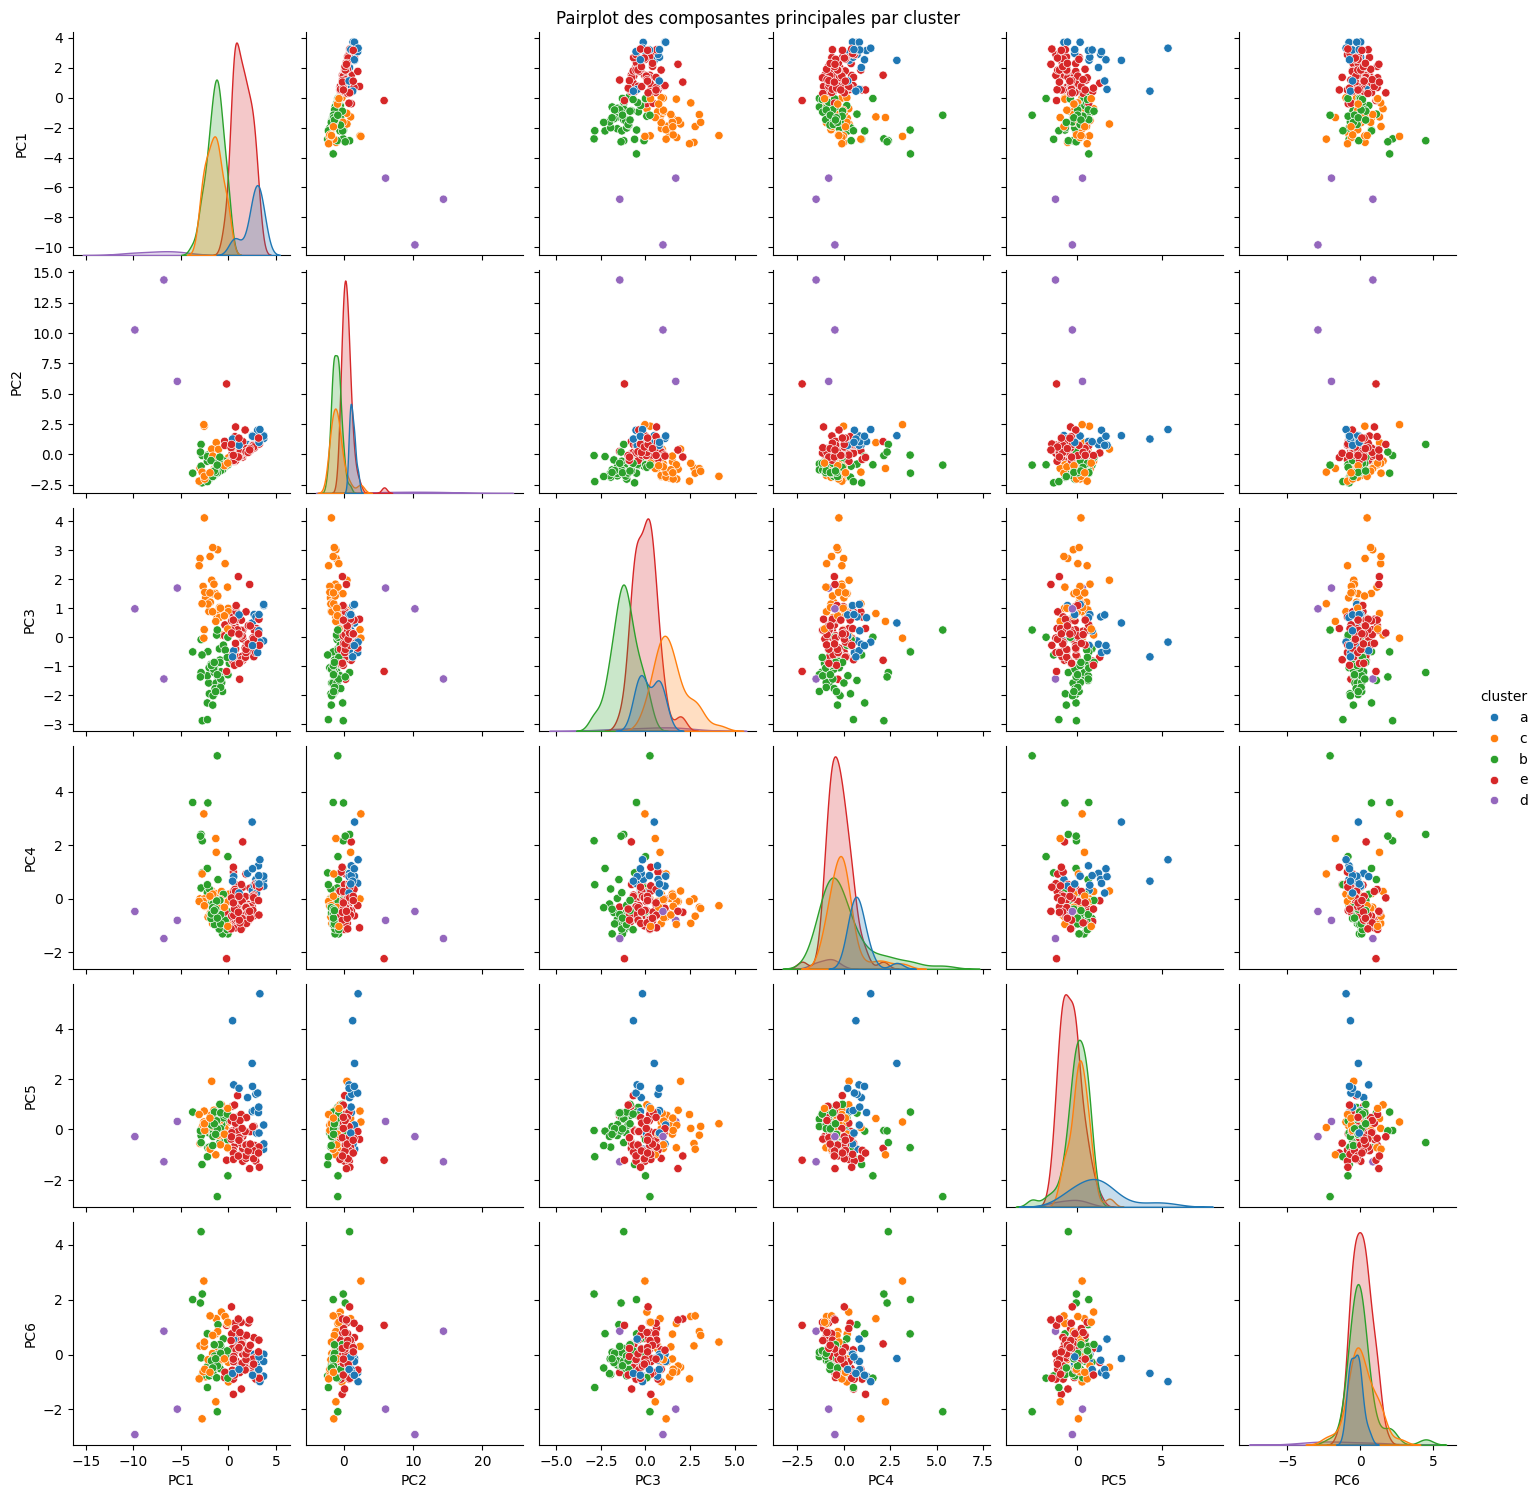

In [552]:
##Affichons les individus sur les différents plans PC, avec une couleur par cluster
pca_df = pd.DataFrame(X_proj[:, :6], index=pays, columns=[f'PC{i+1}' for i in range(6)])
pca_df['cluster'] = scaled_df['cluster']

sns.pairplot(pca_df, hue="cluster", diag_kind="kde", height=2.5)
plt.suptitle('Pairplot des composantes principales par cluster',y=1)
plt.show()

##4.3 : Nos clusters

In [553]:
##On ajoutes les étiquettes de cluster au df originel
df_cleaned["cluster"]=scaled_df["cluster"]

##On réintroduit les unités par souci de lisibilité
df_cleaned.rename(columns={
    'Croissance démographique' : 'Croissance démographique (%)',
    'Disponibilité alimentaire' : 'Disponibilité alimentaire (kg/pers/an)',
    'Disponibilité intérieure' : 'Disponibilité intérieure (x1000 T)',
    'Importations' : 'Importations (x1000 T)',
    'Nourriture' : 'Nourriture (x1000 T)',
    'Production' : 'Production (x1000 T)',
    'Consommation de poulet' : 'Consommation de poulet(kg/an/pers)',
    'Distance' : 'Distance (km)',
    'Inflation' : 'Inflation (%)',
    'PIB par habitant' : 'PIB par hab ($)',
    'Part des céréales' : 'Part des céréales (%)',
    'Sous-alimentation' : 'Sous-alimentation (%)',
    }, inplace=True)

###4.3.1 : Premier cluster

In [554]:
cluster_a=df_cleaned.loc[df_cleaned['cluster'] == 'a']
display(cluster_a.index)

Index(['Afghanistan', 'Angola', 'Ghana', 'Guinée', 'Haïti', 'Kenya', 'Libéria',
       'Madagascar', 'Malawi', 'Mozambique', 'Nigéria', 'Ouzbékistan',
       'Sierra Leone', 'Soudan', 'Ukraine',
       'Venezuela (République bolivarienne du)', 'Yémen', 'Zambie'],
      dtype='object')

In [555]:
print(cluster_a.shape[0], "pays dans ce cluster")

18 pays dans ce cluster


###4.3.2 : Second cluster

In [556]:
cluster_b=df_cleaned.loc[df_cleaned['cluster'] == 'b']
display(cluster_b.index)

Index(['Albanie', 'Allemagne', 'Arabie saoudite', 'Arménie', 'Autriche',
       'Belgique', 'Bosnie-Herzégovine', 'Bulgarie', 'Bélarus', 'Canada',
       'Chine - RAS de Hong-Kong', 'Chine - RAS de Macao', 'Chypre', 'Croatie',
       'Danemark', 'Espagne', 'Estonie', 'Finlande', 'France', 'Grèce',
       'Hongrie', 'Irlande', 'Islande', 'Italie', 'Japon', 'Kazakhstan',
       'Lettonie', 'Lituanie', 'Luxembourg', 'Macédoine du Nord', 'Malte',
       'Monténégro', 'Norvège', 'Oman', 'Pologne', 'Portugal', 'Roumanie',
       'Royaume-Uni de Grande-Bretagne et d'Irlande du Nord',
       'République de Corée', 'République de Moldova',
       'République dominicaine', 'Slovaquie', 'Slovénie', 'Suisse', 'Suède',
       'Tchéquie', 'Émirats arabes unis'],
      dtype='object')

In [557]:
print(cluster_b.shape[0], "pays dans ce cluster")

47 pays dans ce cluster


###4.3.3 : Troisième cluster

In [558]:
cluster_c=df_cleaned.loc[df_cleaned['cluster'] == 'c']
display(cluster_c.index)

Index(['Afrique du Sud', 'Antigua-et-Barbuda', 'Argentine', 'Australie',
       'Bahamas', 'Barbade', 'Belize', 'Bolivie (État plurinational de)',
       'Chili', 'Chine, Taiwan Province de', 'Colombie', 'Costa Rica', 'Cuba',
       'Dominique', 'Fidji', 'Fédération de Russie', 'Grenade', 'Guyana',
       'Israël', 'Jamaïque', 'Kiribati', 'Koweït', 'Malaisie', 'Maurice',
       'Mexique', 'Nouvelle-Calédonie', 'Nouvelle-Zélande', 'Panama',
       'Polynésie française', 'Saint-Kitts-et-Nevis',
       'Saint-Vincent-et-les Grenadines', 'Sainte-Lucie', 'Samoa', 'Suriname',
       'Trinité-et-Tobago', 'Uruguay'],
      dtype='object')

In [559]:
print(cluster_c.shape[0], "pays dans ce cluster")

36 pays dans ce cluster


###4.3.4 : Quatrième cluster

In [560]:
cluster_d=df_cleaned.loc[df_cleaned['cluster'] == 'd']
display(cluster_d.index)

Index(['Brésil', 'Chine, continentale', 'États-Unis d'Amérique'], dtype='object')

In [561]:
print(cluster_d.shape[0], "pays dans ce cluster")

3 pays dans ce cluster


###4.3.5 : Cinquième cluster

In [562]:
cluster_e=df_cleaned.loc[df_cleaned['cluster'] == 'e']
display(cluster_e.index)

Index(['Algérie', 'Azerbaïdjan', 'Bangladesh', 'Botswana', 'Burkina Faso',
       'Bénin', 'Cabo Verde', 'Cambodge', 'Cameroun', 'Congo', 'Côte d'Ivoire',
       'Djibouti', 'El Salvador', 'Eswatini', 'Gabon', 'Gambie', 'Guatemala',
       'Guinée-Bissau', 'Géorgie', 'Honduras', 'Inde', 'Indonésie',
       'Iran (République islamique d')', 'Iraq', 'Jordanie', 'Kirghizistan',
       'Lesotho', 'Liban', 'Maldives', 'Mali', 'Maroc', 'Mauritanie',
       'Mongolie', 'Myanmar', 'Namibie', 'Nicaragua', 'Niger', 'Népal',
       'Ouganda', 'Pakistan', 'Paraguay', 'Philippines', 'Pérou', 'Rwanda',
       'République centrafricaine', 'République démocratique populaire lao',
       'République populaire démocratique de Corée',
       'République-Unie de Tanzanie', 'Sao Tomé-et-Principe', 'Serbie',
       'Sri Lanka', 'Sénégal', 'Tadjikistan', 'Tchad', 'Thaïlande',
       'Timor-Leste', 'Togo', 'Tunisie', 'Turkménistan', 'Vanuatu', 'Viet Nam',
       'Zimbabwe', 'Égypte', 'Équateur', 'Éthiopie', '

In [563]:
print(cluster_e.shape[0], "pays dans ce cluster")

66 pays dans ce cluster


###4.3.6 : Individus moyens et visualisation

In [564]:
cluster_a_mean = cluster_a.drop(columns=['cluster']).mean()
cluster_b_mean = cluster_b.drop(columns=['cluster']).mean()
cluster_c_mean = cluster_c.drop(columns=['cluster']).mean()
cluster_d_mean = cluster_d.drop(columns=['cluster']).mean()
cluster_e_mean = cluster_e.drop(columns=['cluster']).mean()

cluster_means = pd.concat([
    cluster_a_mean,
    cluster_b_mean,
    cluster_c_mean,
    cluster_d_mean,
    cluster_e_mean
], axis=1)

cluster_means.columns = ['Cluster A', 'Cluster B', 'Cluster C', 'Cluster D', 'Cluster E']

display(cluster_means)


,Cluster A,Cluster B,Cluster C,Cluster D,Cluster E
Population,3.526727e+07,1.770758e+07,1.612071e+07,6.513135e+08,4.953472e+07
Croissance démographique (%),5.373989e+01,1.510579e+01,2.196917e+01,1.552333e+01,4.295355e+01
Disponibilité alimentaire (kg/pers/an),6.593333e+00,2.377255e+01,4.035194e+01,3.868000e+01,9.561061e+00
Disponibilité intérieure (x1000 T),2.433222e+02,4.399149e+02,5.938056e+02,1.546967e+04,3.506242e+02
Importations (x1000 T),6.458889e+01,1.731915e+02,7.986111e+01,1.926667e+02,3.511515e+01
Nourriture (x1000 T),2.213333e+02,4.287234e+02,5.613611e+02,1.520000e+04,3.120364e+02
Production (x1000 T),1.999667e+02,4.275106e+02,5.450833e+02,1.811700e+04,3.292667e+02
Consommation de poulet(kg/an/pers),7.746222e+00,2.377489e+01,4.054056e+01,3.868000e+01,9.681697e+00
Distance (km),5.927815e+03,2.903763e+03,9.583795e+03,7.970299e+03,6.492382e+03
Inflation (%),1.674989e+01,2.131660e+00,3.370944e+00,7.791333e+00,3.669727e+00


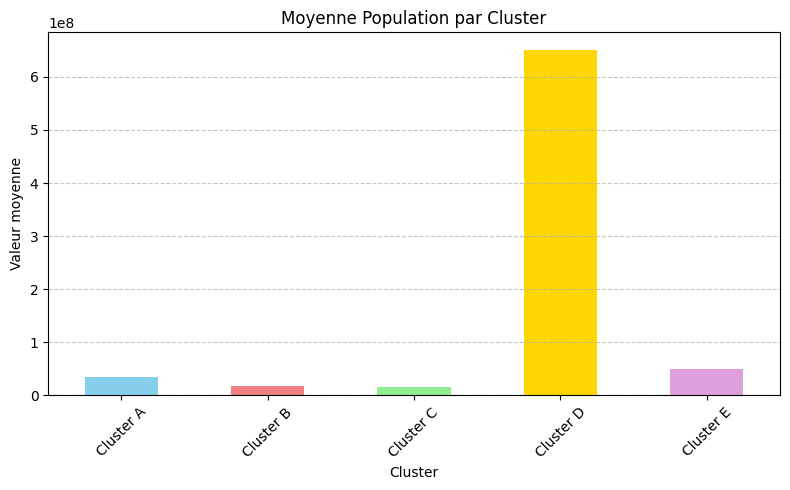

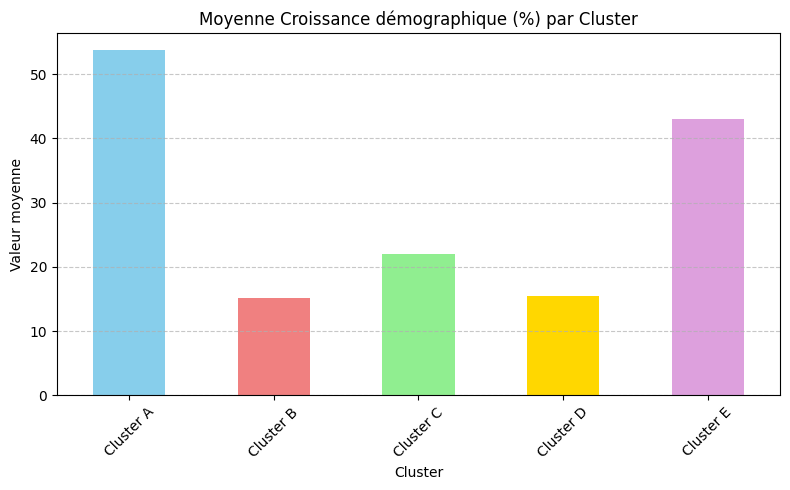

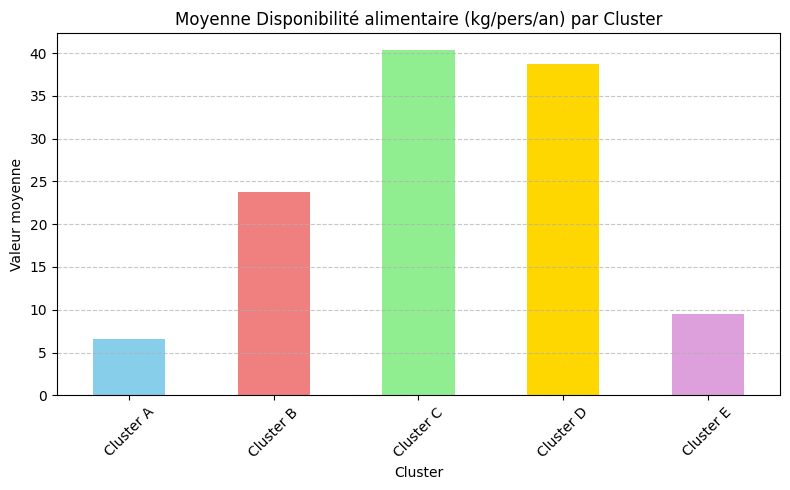

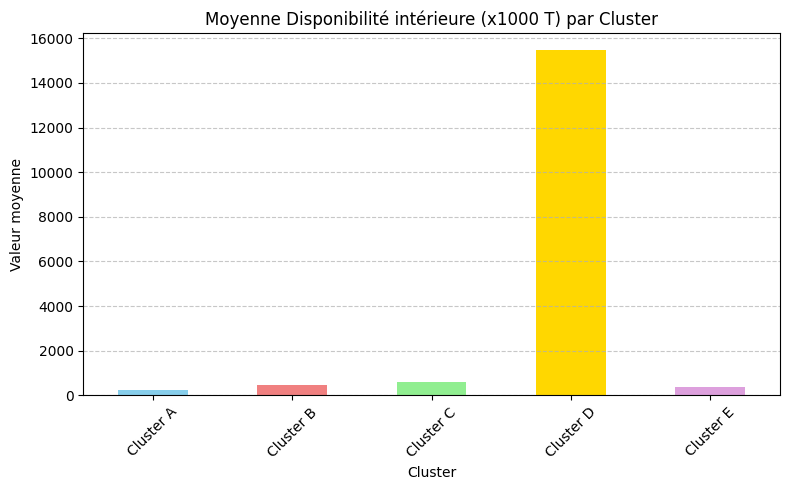

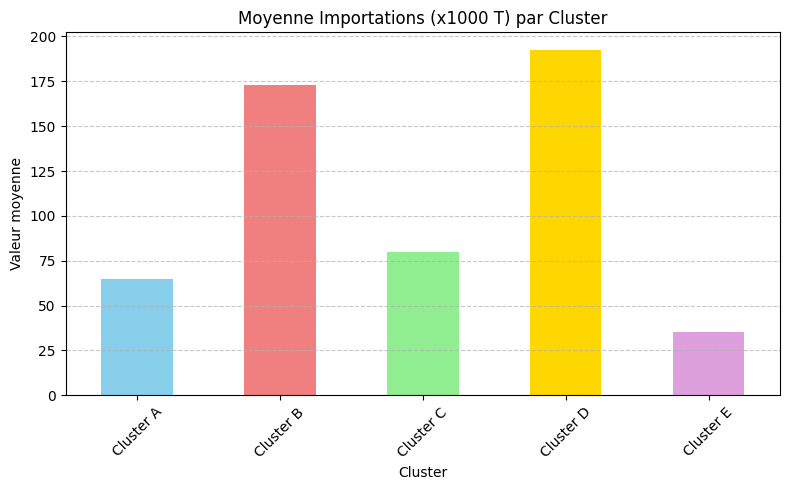

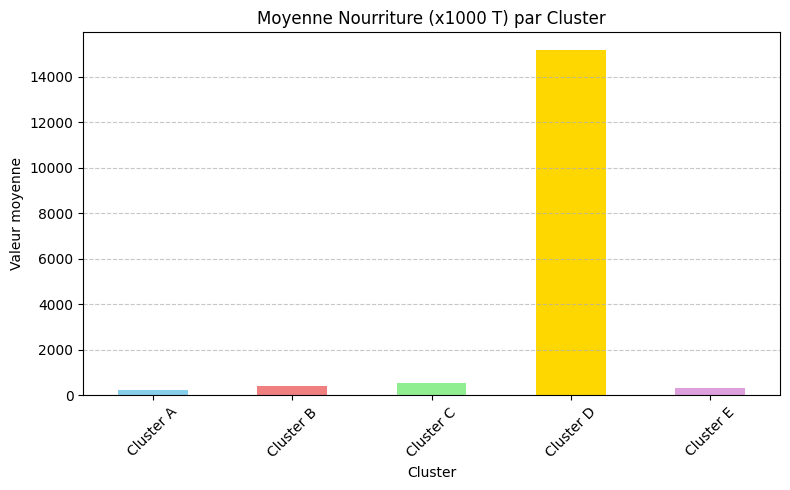

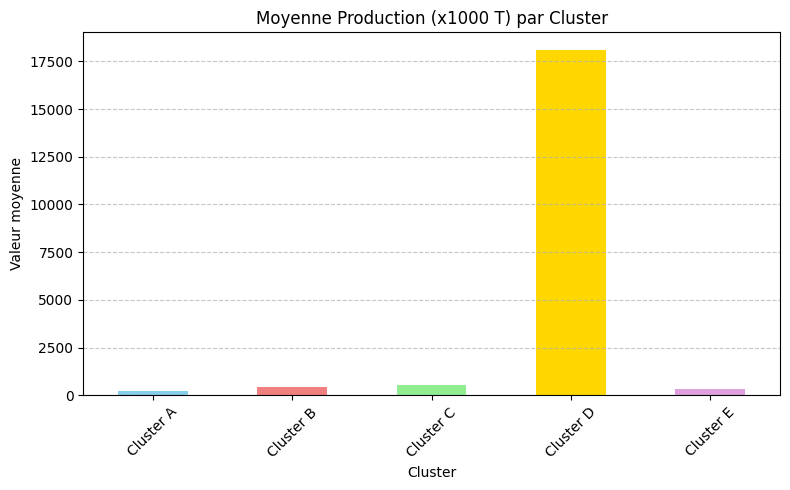

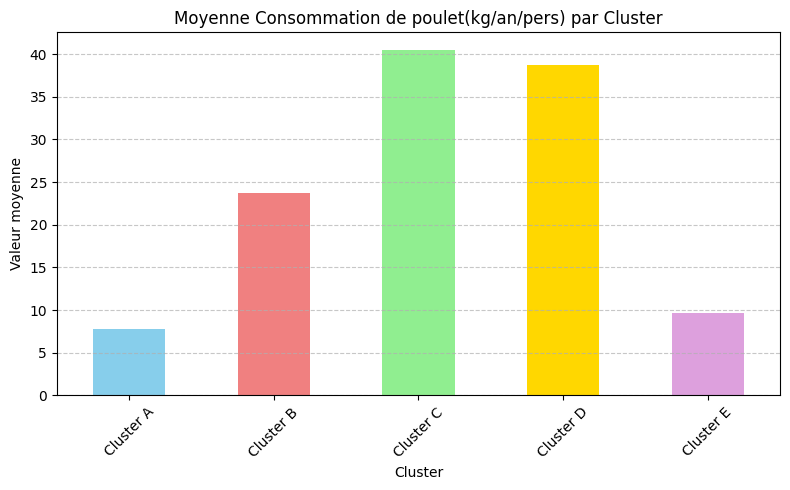

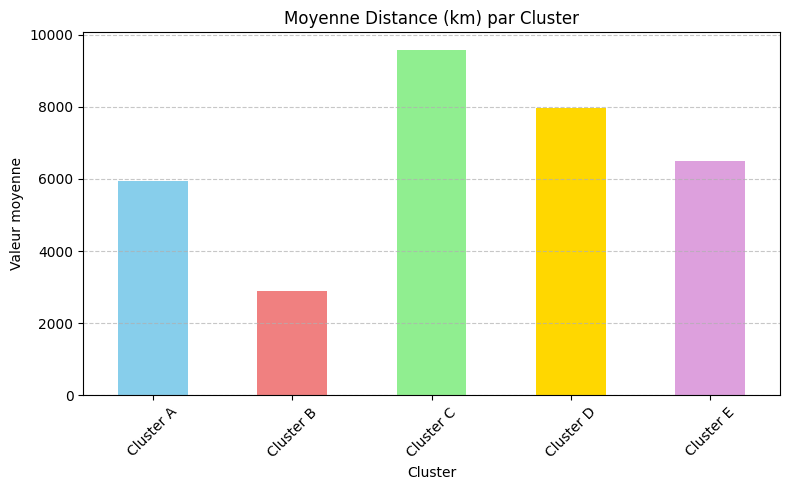

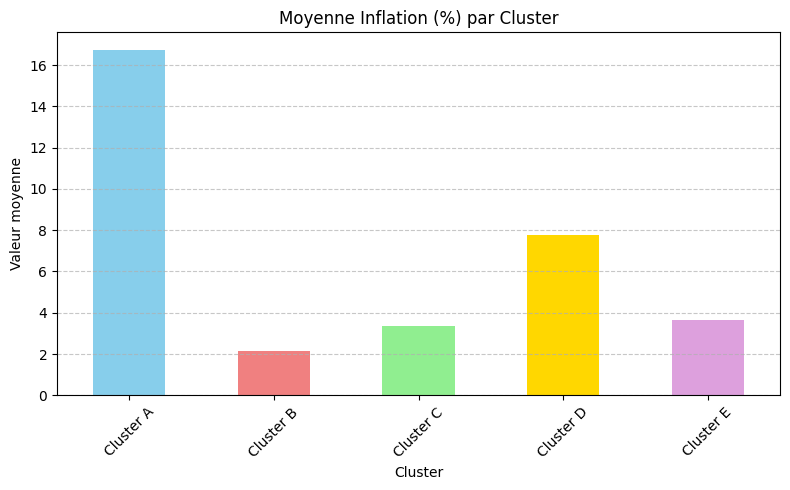

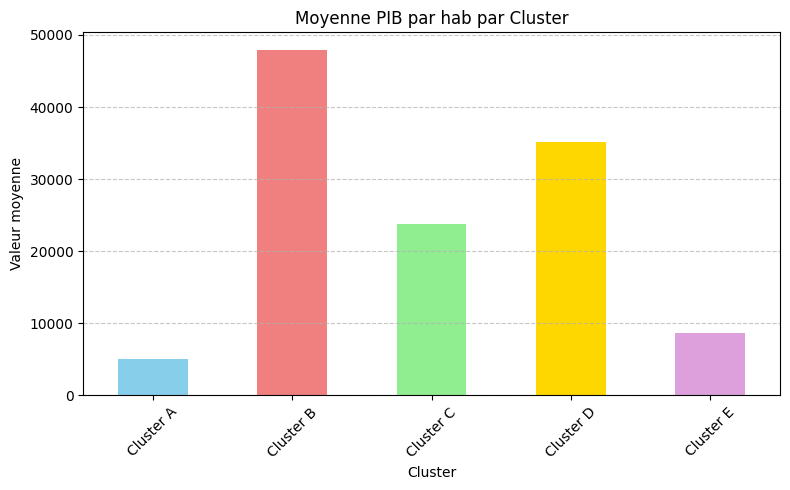

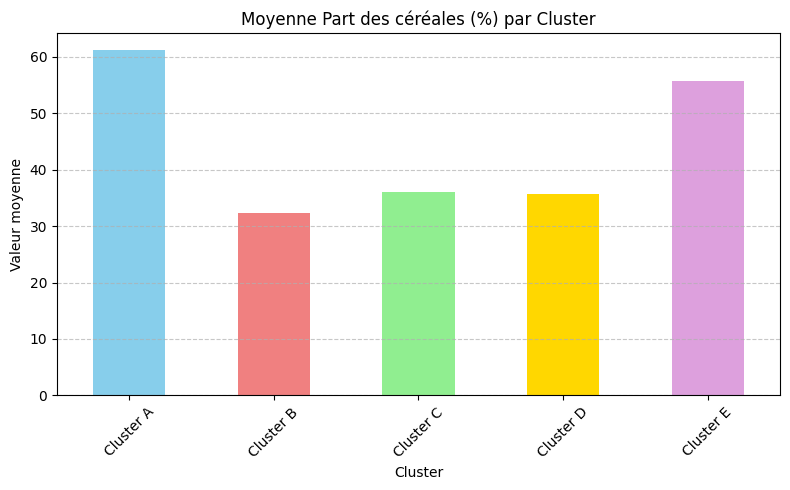

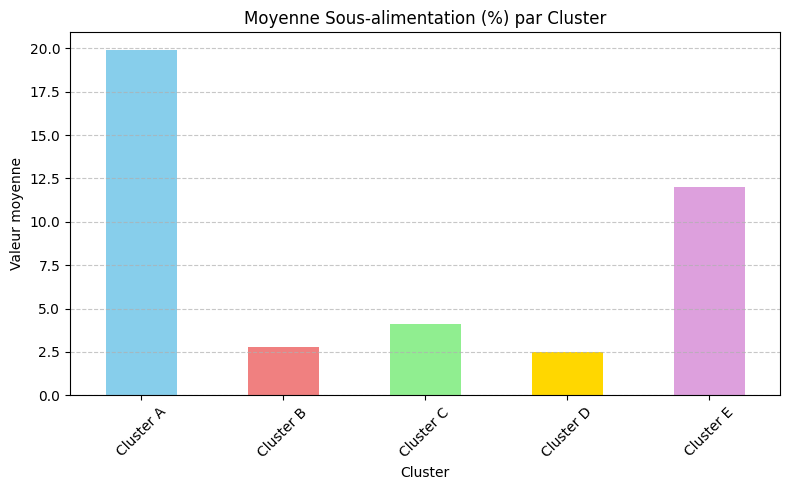

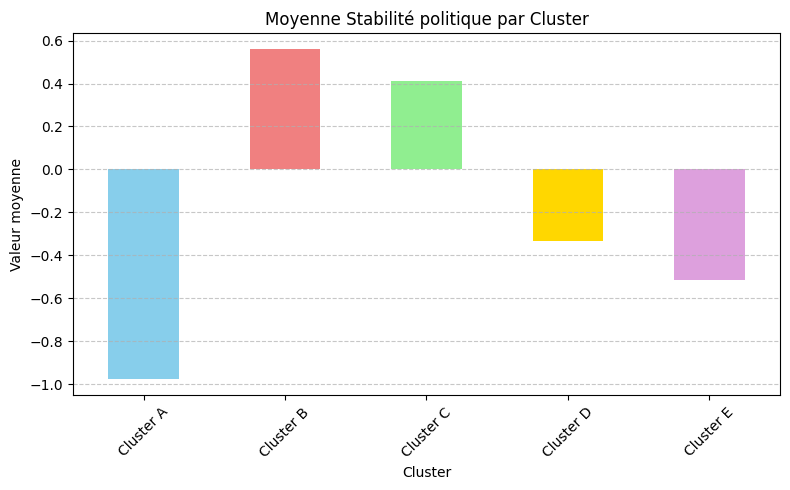

In [565]:
for feature in cluster_means.index:
    plt.figure(figsize=(8, 5))
    cluster_means.loc[feature].plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum'])
    plt.title(f'Moyenne {feature} par Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Valeur moyenne')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

###4.3.7 : Projection avec clusters

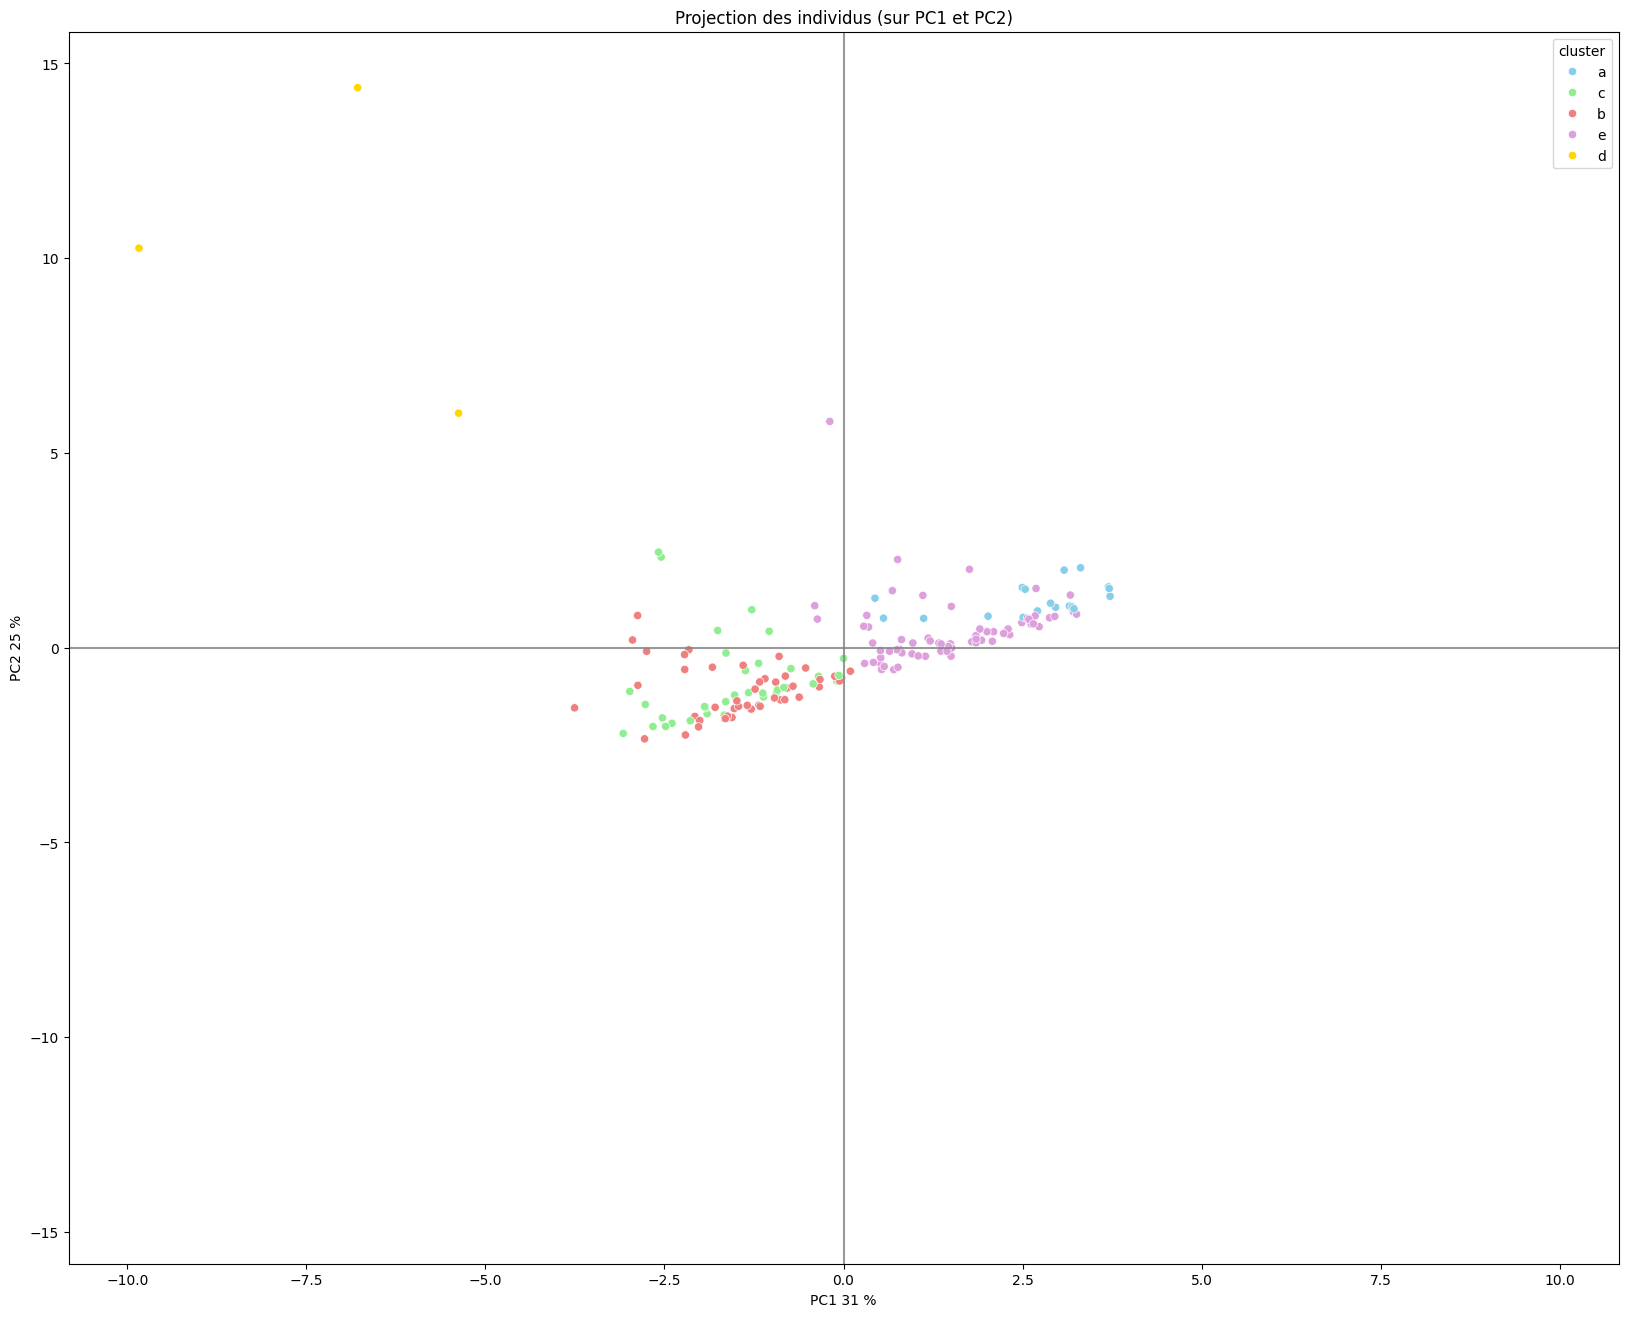

In [566]:
#Graphique pour (PC1,PC2)
x_y = [0,1]
display_factorial_planes(X_proj, x_y, pca, figsize=(20,16), marker="o", clusters=pca_df['cluster'], palette=['skyblue',  'lightgreen','lightcoral', 'plum', 'gold'])

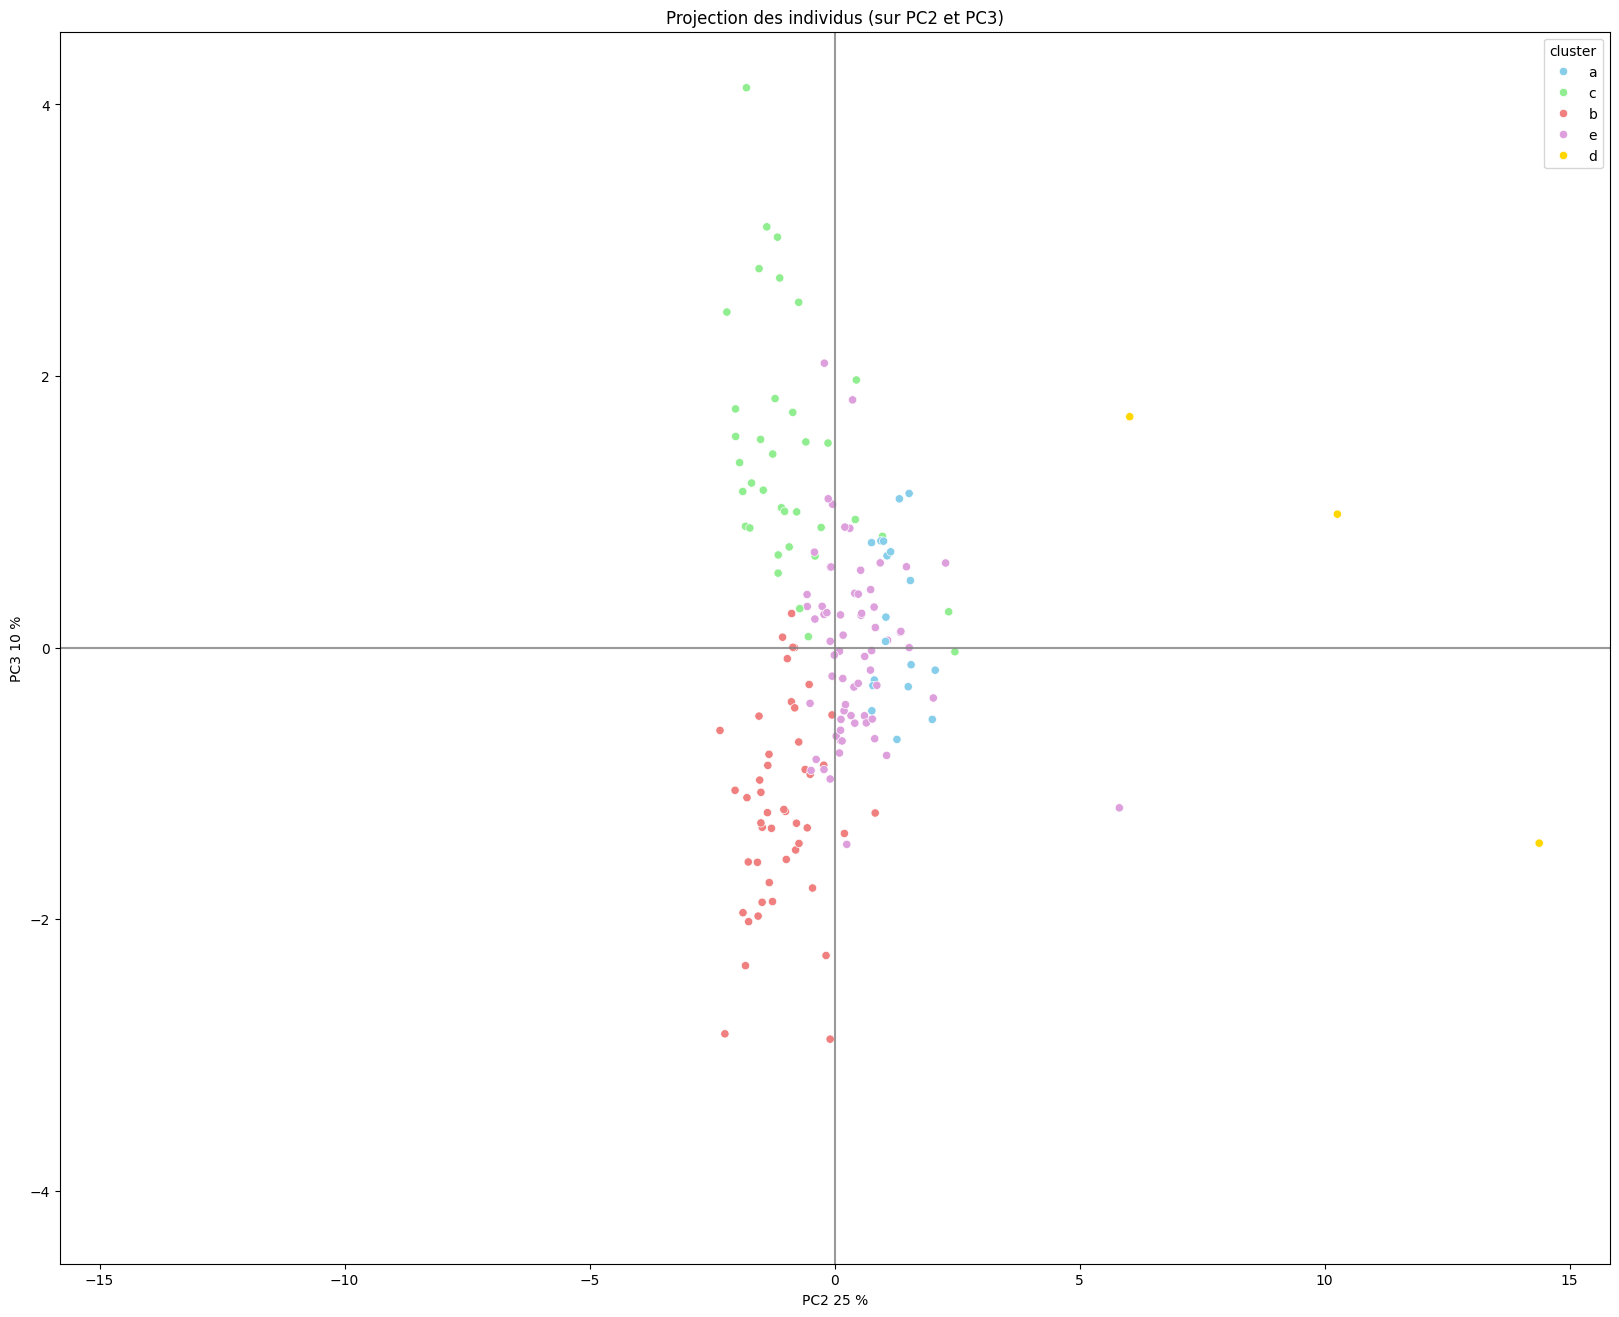

In [567]:
#Graphique pour (PC1,PC2)
x_y = [1,2]
display_factorial_planes(X_proj, x_y, pca, figsize=(20,16), marker="o", clusters=pca_df['cluster'], palette=['skyblue',  'lightgreen','lightcoral', 'plum', 'gold'])

###4.3.8 : Comparaison des deux méthodes

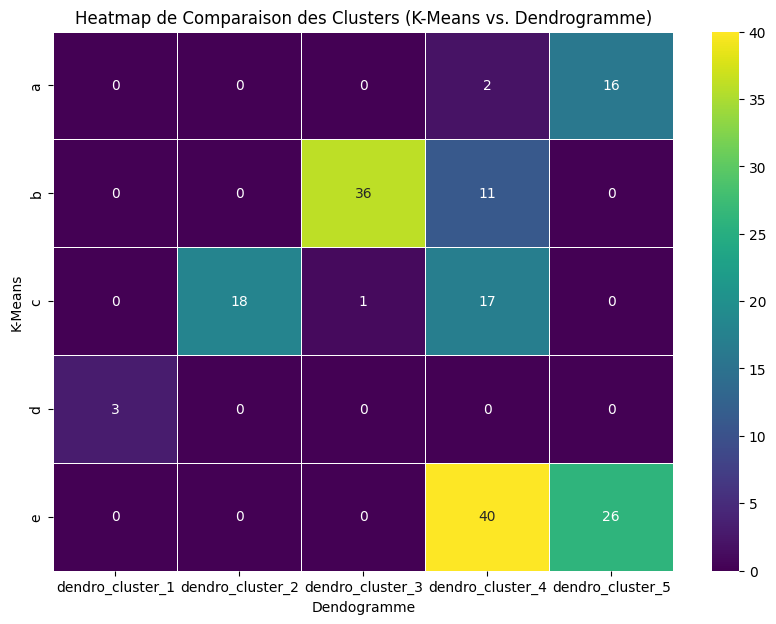

In [568]:
##Etiquetage des clusters issus du dendogramme
dendro_clusters = fcluster(Z, 5, criterion='maxclust')
dendro_labels = ['dendro_cluster_' + str(x) for x in dendro_clusters]

##Dataframe de comparaison
comparison_df = pd.DataFrame({'KMeans_Cluster': df_cleaned['cluster'], 'Dendrogram_Cluster': dendro_labels}, index=pays)

## On affiche le tableau croisé sous forme de heatmap
crosstab_df = pd.crosstab(comparison_df['KMeans_Cluster'], comparison_df['Dendrogram_Cluster'])

plt.figure(figsize=(10, 7))
sns.heatmap(crosstab_df, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Heatmap de Comparaison des Clusters (K-Means vs. Dendrogramme)')
plt.xlabel('Dendogramme')
plt.ylabel('K-Means')
plt.show()